In [1]:
from pathlib import Path
import pickle
import contextlib
import importlib.util
import io
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.ndimage import median_filter
from scipy.signal import medfilt
from scipy.stats import ttest_ind

for candidate in [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'miniVI_PlaceCell_analysis_V4',
    Path.cwd().parent / 'miniVI_PlaceCell_analysis_V4',
]:
    spike_detection_path = candidate / 'utils' / 'spike_detection.py'
    if spike_detection_path.exists():
        break
else:
    raise FileNotFoundError('Could not locate miniVI_PlaceCell_analysis_V4/utils/spike_detection.py')

spike_detection_spec = importlib.util.spec_from_file_location('slm_spike_detection_utils', spike_detection_path)
spike_detection_module = importlib.util.module_from_spec(spike_detection_spec)
spike_detection_spec.loader.exec_module(spike_detection_module)

complex_bursts_detection = spike_detection_module.complex_bursts_detection
detect_bursts_from_vm = spike_detection_module.detect_bursts_from_vm
detect_complex_spikes = spike_detection_module.detect_complex_spikes
interpolate_nan_segment = spike_detection_module.interpolate_nan_segment
refine_all_spikes = spike_detection_module.refine_all_spikes
refine_single_spikes = spike_detection_module.refine_single_spikes
spike_height_calculation2 = spike_detection_module.spike_height_calculation2

preprocess_neural_path = candidate / 'utils' / 'preprocess_neural.py'
if not preprocess_neural_path.exists():
    raise FileNotFoundError('Could not locate miniVI_PlaceCell_analysis_V4/utils/preprocess_neural.py')

preprocess_neural_spec = importlib.util.spec_from_file_location('slm_preprocess_neural_utils', preprocess_neural_path)
preprocess_neural_module = importlib.util.module_from_spec(preprocess_neural_spec)
preprocess_neural_spec.loader.exec_module(preprocess_neural_module)

compute_time_varying_snr_from_trace = preprocess_neural_module.compute_time_varying_snr_from_trace

%load_ext autoreload
%autoreload 2

%matplotlib widget

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sampling_rate_hz = 500
initial_bad_frames = 50
median_filter_window_ms = 101
baseline_window_ms = 100
COLOR_1X = '#009E73'  # Okabe-Ito bluish green: reads as better / healthier
COLOR_20X = '#8C2D04'  # dark reddish brown: reads as worse / stressed, high contrast vs 1x green
median_filter_window_samples = max(1, int(round(median_filter_window_ms * sampling_rate_hz / 1000)))
if median_filter_window_samples % 2 == 0:
    median_filter_window_samples += 1
baseline_window_samples = max(1, int(round(baseline_window_ms * sampling_rate_hz / 1000)))

def interpolate_trace(trace, n_bad_frames=0):
    interpolated = np.asarray(trace, dtype=float).copy()
    interpolated[:n_bad_frames] = np.nan
    nan_mask = np.isnan(interpolated)
    if not nan_mask.any():
        return interpolated
    valid_idx = np.flatnonzero(~nan_mask)
    if valid_idx.size == 0:
        raise ValueError('Trace contains no valid samples after masking bad frames.')
    interpolated[nan_mask] = np.interp(np.flatnonzero(nan_mask), valid_idx, interpolated[valid_idx])
    return interpolated



In [2]:

slm_root = Path('/Volumes/QixinT9/AdamLab/Data/SLM_data')

trace_lists = {'1x': [], '20x': []}
trace_info = {'1x': [], '20x': []}

for folder in sorted(slm_root.iterdir()):
    if not folder.is_dir():
        continue

    folder_name = folder.name
    if folder_name.endswith('_1x'):
        slm_size = '1x'
    elif folder_name.endswith('_20x'):
        slm_size = '20x'
    else:
        continue

    mat_files = sorted(
        path for path in folder.glob('*.mat')
        if not path.name.startswith('._')
    )
    if not mat_files:
        continue

    mat_path = mat_files[0]
    mat_data = loadmat(mat_path)
    if 'intens' not in mat_data:
        raise KeyError(f"'intens' trace not found in {mat_path}")

    trace = np.asarray(mat_data['intens'], dtype=float).squeeze()
    trace = interpolate_trace(trace, n_bad_frames=initial_bad_frames)
    trace_lists[slm_size].append(trace)
    trace_info[slm_size].append(
        {
            'folder': folder_name,
            'mat_file': mat_path.name,
        }
    )

traces_1x = np.stack(trace_lists['1x'])
traces_20x = np.stack(trace_lists['20x'])

print(f"Loaded {traces_1x.shape[0]} traces for 1x: {traces_1x.shape}")
print(f"Loaded {traces_20x.shape[0]} traces for 20x: {traces_20x.shape}")
print(f'Interpolated the first {initial_bad_frames} frames of each trace before analysis.')


Loaded 11 traces for 1x: (11, 300000)
Loaded 9 traces for 20x: (9, 300000)
Interpolated the first 50 frames of each trace before analysis.


Median filter overlay: 101 ms (51 samples at 500 Hz)


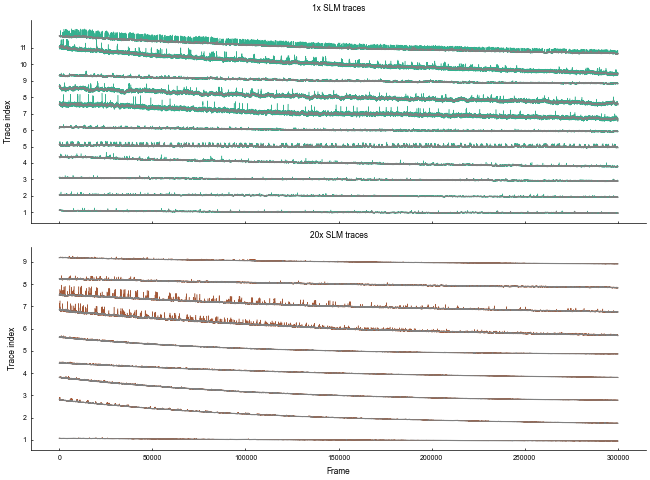

In [3]:
def plot_stacked_traces(ax, traces, title, color):
    filtered_traces = np.vstack([
        medfilt(trace, kernel_size=median_filter_window_samples)
        for trace in traces
    ])
    baseline = np.median(traces, axis=1, keepdims=True)
    centered = traces - baseline
    centered_filtered = filtered_traces - baseline
    amplitudes = np.ptp(centered, axis=1)
    positive_amplitudes = amplitudes[amplitudes > 0]
    spacing = np.median(positive_amplitudes) * 1.2 if positive_amplitudes.size else 1.0

    x = np.arange(traces.shape[1])
    offsets = np.arange(traces.shape[0]) * spacing

    for idx, trace in enumerate(centered):
        ax.plot(x, trace + offsets[idx], color=color, linewidth=0.35, alpha=0.8)
        ax.plot(
            x,
            centered_filtered[idx] + offsets[idx],
            color='0.5',
            linewidth=0.8,
        )

    ax.set_title(title)
    ax.set_ylabel('Trace index')
    ax.set_yticks(offsets)
    ax.set_yticklabels(np.arange(1, traces.shape[0] + 1))
    ax.tick_params(length=1.75, width=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(2, 1, figsize=(6.5, 4.8), sharex=True, constrained_layout=True)

plot_stacked_traces(axes[0], traces_1x, '1x SLM traces', COLOR_1X)
plot_stacked_traces(axes[1], traces_20x, '20x SLM traces', COLOR_20X)

axes[1].set_xlabel('Frame')
print(
    f'Median filter overlay: {median_filter_window_ms} ms '
    f'({median_filter_window_samples} samples at {sampling_rate_hz} Hz)'
)
plt.show()


In [4]:
def normalize_traces_to_filtered_baseline(traces):
    filtered_traces = np.vstack([
        medfilt(trace, kernel_size=median_filter_window_samples)
        for trace in traces
    ])
    baselines = filtered_traces[:, :baseline_window_samples].mean(axis=1, keepdims=True)
    if np.any(baselines == 0):
        raise ValueError('A baseline value is zero; cannot normalize traces.')
    normalized_traces = traces / baselines * 100
    normalized_filtered_traces = filtered_traces / baselines * 100
    return filtered_traces, baselines, normalized_traces, normalized_filtered_traces

filtered_traces_1x, baselines_1x, normalized_traces_1x, normalized_filtered_traces_1x = normalize_traces_to_filtered_baseline(traces_1x)
filtered_traces_20x, baselines_20x, normalized_traces_20x, normalized_filtered_traces_20x = normalize_traces_to_filtered_baseline(traces_20x)
time_s = np.arange(traces_1x.shape[1]) / sampling_rate_hz

print(
    f'Normalized to the first {baseline_window_ms} ms '
    f'({baseline_window_samples} samples) of the median-filtered raw trace.'
)
print(
    f'1x baseline range: {baselines_1x.min():.2f} to {baselines_1x.max():.2f}; '
    f'20x baseline range: {baselines_20x.min():.2f} to {baselines_20x.max():.2f}'
)


Normalized to the first 100 ms (50 samples) of the median-filtered raw trace.
1x baseline range: 543.51 to 2618.52; 20x baseline range: 758.31 to 3981.87


Welch t-test on decay: p=0.00181
Saved summary figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_summary.svg using trace step 75


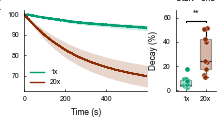

In [5]:
summary_export_max_points = 4000
summary_export_step = max(1, int(np.ceil(time_s.size / summary_export_max_points)))

def plot_mean_sem(ax, traces, label, color, step=1):
    mean_trace = traces.mean(axis=0)
    sem_trace = traces.std(axis=0, ddof=1) / np.sqrt(traces.shape[0])
    plot_time = time_s[::step]
    plot_mean = mean_trace[::step]
    plot_sem = sem_trace[::step]
    ax.plot(plot_time, plot_mean, color=color, linewidth=1.0, label=label)
    ax.fill_between(plot_time, plot_mean - plot_sem, plot_mean + plot_sem, color=color, alpha=0.2, linewidth=0)

def compute_decay(traces):
    start_mean = traces[:, :baseline_window_samples].mean(axis=1)
    end_mean = traces[:, -baseline_window_samples:].mean(axis=1)
    return start_mean - end_mean

def p_to_stars(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return ''

decay_1x = compute_decay(normalized_filtered_traces_1x)
decay_20x = compute_decay(normalized_filtered_traces_20x)
decay_ttest = ttest_ind(decay_1x, decay_20x, equal_var=False)
summary_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_summary.svg')

def build_summary_figure(trace_step=1):
    fig, (ax_trace, ax_box) = plt.subplots(
        1,
        2,
        figsize=(2.2, 1.2),
        gridspec_kw={'width_ratios': [3.1, 1.]},
    )

    plot_mean_sem(ax_trace, normalized_filtered_traces_1x, '1x', COLOR_1X, step=trace_step)
    plot_mean_sem(ax_trace, normalized_filtered_traces_20x, '20x', COLOR_20X, step=trace_step)

    ax_trace.set_xlabel('Time (s)')
    ax_trace.set_ylabel('Normalized fluorescence (%)')
    ax_trace.tick_params(length=1.75, width=0.5)
    ax_trace.spines['top'].set_visible(False)
    ax_trace.spines['right'].set_visible(False)
    ax_trace.legend(frameon=False)
    ax_trace.margins(x=0)

    box = ax_box.boxplot(
        [decay_1x, decay_20x],
        tick_labels=['1x', '20x'],
        widths=0.55,
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 0.8},
        boxprops={'linewidth': 0.8},
        whiskerprops={'linewidth': 0.8},
        capprops={'linewidth': 0.8},
        showfliers=False,
    )
    for patch, color in zip(box['boxes'], [COLOR_1X, COLOR_20X]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    rng = np.random.default_rng(0)
    for x_pos, values, color in zip([1, 2], [decay_1x, decay_20x], [COLOR_1X, COLOR_20X]):
        jitter = rng.uniform(-0.08, 0.08, size=values.shape[0])
        ax_box.scatter(
            np.full(values.shape[0], x_pos) + jitter,
            values,
            s=14,
            color=color,
            edgecolors='white',
            linewidths=0.3,
            zorder=3,
        )

    y_min = min(decay_1x.min(), decay_20x.min())
    y_max = max(decay_1x.max(), decay_20x.max())
    y_range = y_max - y_min if y_max > y_min else 1.0
    line_y = y_max + 0.1 * y_range
    text_y = y_max + 0.18 * y_range
    ax_box.plot([1, 1, 2, 2], [line_y, line_y + 0.03 * y_range, line_y + 0.03 * y_range, line_y], color='black', linewidth=0.8)
    ax_box.text(1.5, text_y, p_to_stars(decay_ttest.pvalue), ha='center', va='bottom', fontsize=6)
    ax_box.set_ylim(y_min - 0.08 * y_range, y_max + 0.32 * y_range)

    ax_box.set_ylabel('Decay (%)')
    ax_box.set_title('Start - end')
    ax_box.tick_params(length=1.75, width=0.5)
    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)

    fig.subplots_adjust(left=0.11, right=0.98, bottom=0.24, top=0.92, wspace=0.35)
    return fig

print(f"Welch t-test on decay: p={decay_ttest.pvalue:.3g}")
fig = build_summary_figure(trace_step=1)
export_fig = build_summary_figure(trace_step=summary_export_step)
export_fig.savefig(summary_figure_path, format='svg', bbox_inches='tight')
plt.close(export_fig)
print(f'Saved summary figure to {summary_figure_path} using trace step {summary_export_step}')
plt.show()


1x mapping (bottom = 1, top = 11):
  1: pAce21_PR_cell3_1x | decay=3.23%
  2: pAce21_BR_cell3_1x | decay=3.27%
  3: pAce21_BR_cell2_1x | decay=3.79%
  4: pAce34_BL_cell2_1x | decay=4.23%
  5: pAce21_BR_cell5_1x | decay=4.33%
  6: pAce46_PX_cell2_1x | decay=4.64%
  7: pAce46_PX_cell8_1x | decay=5.55%
  8: pAce52_BRR_cell4_1x | decay=8.10%
  9: pAce46_PX_cell9_1x | decay=9.29%
  10: pAce21_PR_cell2_1x | decay=9.73%
  11: pAce52_PRL_cell3_1x | decay=17.93%
20x mapping (bottom = 1, top = 9):
  1: pAce52_BRR_cell6_20x | decay=11.02%
  2: pAce21_BR_cell7_20x | decay=13.11%
  3: pAce52_BRR_cell3_20x | decay=17.72%
  4: pAce52_BRR_cell1_20x | decay=23.50%
  5: pAce52_PRL_cell1_20x | decay=24.34%
  6: pAce34_BL_cell3_20x | decay=39.74%
  7: pAce34_BL_cell8_20x | decay=42.22%
  8: pAce34_BL_cell10_20x | decay=50.72%
  9: pAce24_WR_cell7_20x | decay=51.25%
Saved stacked normalized trace figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/S

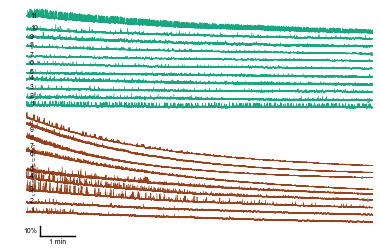

In [6]:
from matplotlib.patches import Rectangle

def prepare_sorted_centered_traces(traces, decay_reference_traces, trace_metadata):
    decay = compute_decay(decay_reference_traces)
    sort_idx = np.argsort(decay)
    sorted_traces = traces[sort_idx]
    centered = sorted_traces - np.median(sorted_traces, axis=1, keepdims=True)
    sorted_metadata = [trace_metadata[idx] for idx in sort_idx]
    return centered, decay[sort_idx], sorted_metadata

centered_1x, sorted_decay_1x, sorted_info_1x = prepare_sorted_centered_traces(normalized_traces_1x, normalized_filtered_traces_1x, trace_info['1x'])
centered_20x, sorted_decay_20x, sorted_info_20x = prepare_sorted_centered_traces(normalized_traces_20x, normalized_filtered_traces_20x, trace_info['20x'])

zoom_duration_s = 2.0
zoom_specs = [
    {'condition': '1x', 'cell_number': 8, 'start_1_s': 7.2, 'start_2_s': 596.5},
    {'condition': '1x', 'cell_number': 2, 'start_1_s': 12.3, 'start_2_s': 590},
    {'condition': '20x', 'cell_number': 7, 'start_1_s': 10.2, 'start_2_s': 580},
    {'condition': '20x', 'cell_number': 4, 'start_1_s': 12.3, 'start_2_s': 590},
]

global_max_decay = max(sorted_decay_1x.max(), sorted_decay_20x.max())
shared_half_range = max(6.0, 0.5 * global_max_decay)
shared_ylim = (-shared_half_range, shared_half_range)
trace_total_duration_s = centered_1x.shape[1] / sampling_rate_hz

def add_scale_bars(ax, y_limits, vertical_bar_height=10.0, horizontal_bar_width_s=60.0):
    x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
    x_right = x_left + horizontal_bar_width_s
    y0 = y_limits[0] + 0.14 * (y_limits[1] - y_limits[0])
    ax.plot([x_left, x_left], [y0, y0 + vertical_bar_height], color='black', linewidth=1.0, clip_on=False)
    ax.text(x_left - time_s[-1] * 0.01, y0 + vertical_bar_height / 2, '10%', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y0, y0], color='black', linewidth=1.0, clip_on=False)
    ax.text((x_left + x_right) / 2, y0 - 0.06 * (y_limits[1] - y_limits[0]), '1 min', ha='center', va='top', fontsize=5)

def clip_zoom_window(start_s, duration_s, total_duration_s):
    clipped_start_s = min(max(0.0, float(start_s)), total_duration_s)
    clipped_end_s = min(total_duration_s, clipped_start_s + float(duration_s))
    return clipped_start_s, clipped_end_s

def get_trace_segment_box_bounds(trace, start_s, end_s, y_limits):
    start_idx = int(round(start_s * sampling_rate_hz))
    end_idx = max(start_idx + 1, int(round(end_s * sampling_rate_hz)))
    end_idx = min(trace.size, end_idx)
    segment = np.asarray(trace[start_idx:end_idx], dtype=float)
    finite_segment = segment[np.isfinite(segment)]
    if finite_segment.size == 0:
        center_y = 0.0
        segment_min = center_y - 0.5
        segment_max = center_y + 0.5
    else:
        segment_min = float(np.nanmin(finite_segment))
        segment_max = float(np.nanmax(finite_segment))
        if segment_max <= segment_min:
            segment_max = segment_min + 1e-3
    segment_range = segment_max - segment_min
    padding = max(0.5, 0.18 * max(segment_range, 0.5))
    box_y0 = max(y_limits[0], segment_min - padding)
    box_y1 = min(y_limits[1], segment_max + padding)
    if box_y1 <= box_y0:
        box_y0, box_y1 = y_limits
    return box_y0, box_y1

stacked_normalized_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_normalized_stacked.svg')
group_sizes = [centered_1x.shape[0], centered_20x.shape[0]]
inter_group_gap_rows = 5
total_rows = sum(group_sizes) + inter_group_gap_rows * (len(group_sizes) - 1)
fig, axes = plt.subplots(total_rows, 1, figsize=(3.8, total_rows * 0.1), sharex=True, sharey=True)
if total_rows == 1:
    axes = np.array([axes])

for ax in axes.ravel():
    ax.set_visible(False)

condition_specs = [
    ('1x', centered_1x, COLOR_1X),
    ('20x', centered_20x, COLOR_20X),
]

for condition_label, sorted_info, sorted_decay in [
    ('1x', sorted_info_1x, sorted_decay_1x),
    ('20x', sorted_info_20x, sorted_decay_20x),
]:
    print(f'{condition_label} mapping (bottom = 1, top = {len(sorted_info)}):')
    for rank, (info, decay_value) in enumerate(zip(sorted_info, sorted_decay), start=1):
        print(f"  {rank}: {info['folder']} | decay={decay_value:.2f}%")

centered_trace_lookup = {
    '1x': centered_1x,
    '20x': centered_20x,
}

display_axis_lookup = {condition_label: {} for condition_label, _, _ in condition_specs}
row_cursor = 0
for group_idx, (condition_label, centered_traces, color) in enumerate(condition_specs):
    n_traces = centered_traces.shape[0]
    for rank, trace in enumerate(centered_traces):
        display_number = rank + 1
        row_idx = row_cursor + (n_traces - 1 - rank)
        ax = axes[row_idx]
        ax.set_visible(True)
        ax.patch.set_alpha(0)
        ax.plot(time_s, trace, color=color, linewidth=0.25, alpha=0.9, clip_on=False)
        ax.set_ylim(shared_ylim)
        ax.margins(x=0, y=0)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
        if group_idx == len(condition_specs) - 1 and rank == 0:
            add_scale_bars(ax, shared_ylim)
        label_x = time_s[0] + 0.01 * (time_s[-1] - time_s[0])
        label_idx = np.searchsorted(time_s, label_x)
        label_window = trace[max(0, label_idx - 5):min(trace.size, label_idx + 6)]
        label_vertical_offset = 1.5
        label_y = np.clip(label_window.mean() + label_vertical_offset, shared_ylim[0] + 1.0, shared_ylim[1] - 1.0)
        ax.text(label_x, label_y, str(display_number), ha='left', va='center', fontsize=5)
        display_axis_lookup[condition_label][display_number] = ax
    row_cursor += n_traces
    if group_idx < len(condition_specs) - 1:
        row_cursor += inter_group_gap_rows

for zoom_spec in zoom_specs:
    condition_label = zoom_spec['condition']
    cell_number = int(zoom_spec['cell_number'])
    if cell_number not in display_axis_lookup[condition_label]:
        raise ValueError(f"Invalid displayed cell number {cell_number} for condition {condition_label}.")
    ax = display_axis_lookup[condition_label][cell_number]
    trace = centered_trace_lookup[condition_label][cell_number - 1]
    for start_key in ('start_1_s', 'start_2_s'):
        start_s, end_s = clip_zoom_window(zoom_spec[start_key], zoom_duration_s, trace_total_duration_s)
        box_y0, box_y1 = get_trace_segment_box_bounds(trace, start_s, end_s, shared_ylim)
        ax.add_patch(
            Rectangle(
                (start_s, box_y0),
                max(0.0, end_s - start_s),
                box_y1 - box_y0,
                fill=False,
                edgecolor='0.55',
                linewidth=0.7,
                linestyle='--',
                clip_on=False,
                zorder=4,
            )
        )

fig.subplots_adjust(left=0.07, right=0.98, bottom=0.03, top=0.99, hspace=-0.84)
fig.savefig(stacked_normalized_figure_path, format='svg', bbox_inches='tight')
print(f'Saved stacked normalized trace figure to {stacked_normalized_figure_path}')
plt.show()


In [7]:
try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError('Install plotly in this notebook environment, for example with `pip install plotly`.') from exc

plotly_stacked_normalized_figure_path = stacked_normalized_figure_path.with_name(
    'SLM_comparison_normalized_stacked_plotly.html'
)

# Controls: y units are the same normalized percent units as the centered traces.
plotly_vertical_offset = 7.0
plotly_trace_step = 1
plotly_line_width = 0.45
plotly_inter_group_gap_rows = inter_group_gap_rows
plotly_fig_height = max(360, int((sum(group_sizes) + plotly_inter_group_gap_rows) * 12))

plotly_time_s = time_s[::plotly_trace_step]
plotly_condition_specs = [
    ('1x', centered_1x, COLOR_1X),
    ('20x', centered_20x, COLOR_20X),
]
plotly_group_sizes = [traces.shape[0] for _, traces, _ in plotly_condition_specs]
plotly_total_rows = sum(plotly_group_sizes) + plotly_inter_group_gap_rows * (len(plotly_group_sizes) - 1)

fig = go.Figure()
plotly_offset_lookup = {condition_label: {} for condition_label, _, _ in plotly_condition_specs}
plotly_group_offset_bounds = {}
row_cursor = 0

for group_idx, (condition_label, centered_traces, color) in enumerate(plotly_condition_specs):
    n_traces = centered_traces.shape[0]
    group_offsets = []

    for rank, trace in enumerate(centered_traces):
        display_number = rank + 1
        row_idx = row_cursor + (n_traces - 1 - rank)
        axis_row = plotly_total_rows - 1 - row_idx
        y_offset = axis_row * plotly_vertical_offset
        group_offsets.append(y_offset)
        plotly_offset_lookup[condition_label][display_number] = y_offset

        plot_trace = np.asarray(trace[::plotly_trace_step], dtype=float)
        fig.add_trace(
            go.Scattergl(
                x=plotly_time_s,
                y=plot_trace + y_offset,
                customdata=plot_trace,
                mode='lines',
                line=dict(color=color, width=plotly_line_width),
                opacity=0.9,
                name=condition_label,
                legendgroup=condition_label,
                showlegend=False,
                hovertemplate=(
                    f'{condition_label} cell {display_number}<br>'
                    'time=%{x:.2f} s<br>'
                    'centered=%{customdata:.2f}%<extra></extra>'
                ),
            )
        )

        label_x = time_s[0] + 0.01 * (time_s[-1] - time_s[0])
        label_idx = np.searchsorted(time_s, label_x)
        label_window = trace[max(0, label_idx - 5):min(trace.size, label_idx + 6)]
        label_y = np.clip(
            np.nanmean(label_window) + 1.5,
            shared_ylim[0] + 1.0,
            shared_ylim[1] - 1.0,
        ) + y_offset
        fig.add_annotation(
            x=label_x,
            y=label_y,
            text=str(display_number),
            showarrow=False,
            xanchor='left',
            yanchor='middle',
            font=dict(size=8, color='black'),
        )

    plotly_group_offset_bounds[condition_label] = (min(group_offsets), max(group_offsets))
    row_cursor += n_traces
    if group_idx < len(plotly_condition_specs) - 1:
        row_cursor += plotly_inter_group_gap_rows

for zoom_spec in zoom_specs:
    condition_label = zoom_spec['condition']
    cell_number = int(zoom_spec['cell_number'])
    if cell_number not in plotly_offset_lookup[condition_label]:
        raise ValueError(f"Invalid displayed cell number {cell_number} for condition {condition_label}.")

    trace = centered_trace_lookup[condition_label][cell_number - 1]
    y_offset = plotly_offset_lookup[condition_label][cell_number]
    for start_key in ('start_1_s', 'start_2_s'):
        start_s, end_s = clip_zoom_window(zoom_spec[start_key], zoom_duration_s, trace_total_duration_s)
        box_y0, box_y1 = get_trace_segment_box_bounds(trace, start_s, end_s, shared_ylim)
        fig.add_shape(
            type='rect',
            x0=start_s,
            x1=end_s,
            y0=box_y0 + y_offset,
            y1=box_y1 + y_offset,
            line=dict(color='rgba(90, 90, 90, 0.85)', width=0.8, dash='dash'),
            fillcolor='rgba(0, 0, 0, 0)',
            layer='above',
        )

scale_condition = plotly_condition_specs[-1][0]
scale_cell_number = 1
scale_y_offset = plotly_offset_lookup[scale_condition][scale_cell_number]
scale_x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
scale_x_right = scale_x_left + 60.0
scale_y0 = scale_y_offset + shared_ylim[0] + 0.14 * (shared_ylim[1] - shared_ylim[0])
scale_y1 = scale_y0 + 10.0
fig.add_shape(
    type='line',
    x0=scale_x_left,
    x1=scale_x_left,
    y0=scale_y0,
    y1=scale_y1,
    line=dict(color='black', width=1.0),
)
fig.add_annotation(
    x=scale_x_left - time_s[-1] * 0.01,
    y=(scale_y0 + scale_y1) / 2,
    text='10%',
    showarrow=False,
    xanchor='right',
    yanchor='middle',
    font=dict(size=8, color='black'),
)
fig.add_shape(
    type='line',
    x0=scale_x_left,
    x1=scale_x_right,
    y0=scale_y0,
    y1=scale_y0,
    line=dict(color='black', width=1.0),
)
fig.add_annotation(
    x=(scale_x_left + scale_x_right) / 2,
    y=scale_y0 - 0.06 * (shared_ylim[1] - shared_ylim[0]),
    text='1 min',
    showarrow=False,
    xanchor='center',
    yanchor='top',
    font=dict(size=8, color='black'),
)

for condition_label, _, color in plotly_condition_specs:
    y_min, y_max = plotly_group_offset_bounds[condition_label]
    fig.add_annotation(
        x=time_s[-1],
        y=(y_min + y_max) / 2,
        text=condition_label,
        showarrow=False,
        xanchor='right',
        yanchor='middle',
        font=dict(size=9, color=color),
    )

all_offsets = [offset for offsets in plotly_offset_lookup.values() for offset in offsets.values()]
y_padding = max(2.0, 0.35 * plotly_vertical_offset)
fig.update_layout(
    template='simple_white',
    width=900,
    height=plotly_fig_height,
    margin=dict(l=35, r=20, t=18, b=28),
    hovermode='closest',
)
fig.update_xaxes(
    range=[float(time_s[0]), float(time_s[-1])],
    showgrid=False,
    zeroline=False,
    title_text='Time (s)',
)
fig.update_yaxes(
    range=[min(all_offsets) + shared_ylim[0] - y_padding, max(all_offsets) + shared_ylim[1] + y_padding],
    showgrid=False,
    zeroline=False,
    showticklabels=False,
    ticks='',
    title_text=f'Centered normalized traces, offset={plotly_vertical_offset:g}%',
)

fig.write_html(plotly_stacked_normalized_figure_path, include_plotlyjs='cdn')
print(f'Saved Plotly stacked normalized trace figure to {plotly_stacked_normalized_figure_path}')


Saved Plotly stacked normalized trace figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_normalized_stacked_plotly.html


Saved normalized zoom panel figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_normalized_zoom_panels.svg


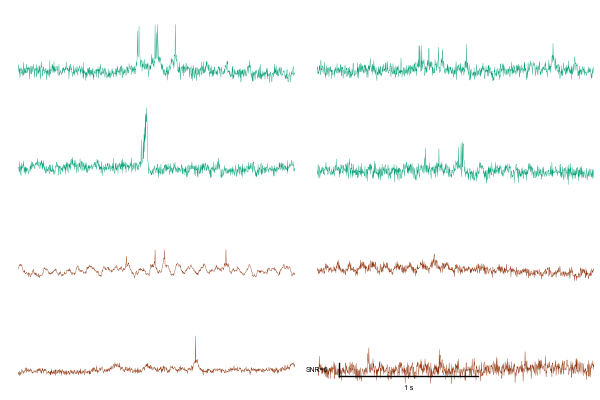

In [8]:
zoom_panel_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_normalized_zoom_panels.svg')
zoom_panel_figsize = (6, 4)
zoom_panel_scale_bar_time_s = 1.0
zoom_panel_scale_bar_height = 6
zoom_panel_specs = zoom_specs
zoom_panel_duration_s = zoom_duration_s
zoom_panel_detrend_window_s = 10.0
zoom_panel_local_zscore_window_s = 30.0
zoom_panel_detrend_window_samples = max(1, int(round(zoom_panel_detrend_window_s * sampling_rate_hz)))
if zoom_panel_detrend_window_samples % 2 == 0:
    zoom_panel_detrend_window_samples += 1

sorted_raw_trace_lookup = {
    '1x': traces_1x[np.argsort(compute_decay(normalized_filtered_traces_1x))],
    '20x': traces_20x[np.argsort(compute_decay(normalized_filtered_traces_20x))],
}

def get_raw_trace_by_display_number(condition_label, cell_number):
    raw_traces = sorted_raw_trace_lookup[condition_label]
    if not 1 <= int(cell_number) <= raw_traces.shape[0]:
        raise ValueError(
            f"Invalid displayed cell number {cell_number} for condition {condition_label}. "
            f"Valid range is 1-{raw_traces.shape[0]}."
        )
    return np.asarray(raw_traces[int(cell_number) - 1], dtype=float)

def compute_detrended_trace(trace, detrend_window_samples):
    raw_trace = np.asarray(trace, dtype=float)
    subthreshold_trace = medfilt(raw_trace, kernel_size=median_filter_window_samples)
    slow_trend_trace = medfilt(subthreshold_trace, kernel_size=detrend_window_samples)
    detrended_trace = raw_trace - slow_trend_trace
    detrended_subthreshold_trace = subthreshold_trace - slow_trend_trace
    return detrended_trace, detrended_subthreshold_trace

def compute_local_trace_zscore_params(detrended_subthreshold_trace, center_s, window_s=30.0):
    half_window_s = 0.5 * float(window_s)
    window_start_s = max(0.0, float(center_s) - half_window_s)
    clipped_start_s, clipped_end_s = clip_zoom_window(window_start_s, window_s, detrended_subthreshold_trace.size / sampling_rate_hz)
    start_idx = int(round(clipped_start_s * sampling_rate_hz))
    end_idx = max(start_idx + 1, int(round(clipped_end_s * sampling_rate_hz)))
    end_idx = min(detrended_subthreshold_trace.size, end_idx)
    filtered_window = np.asarray(detrended_subthreshold_trace[start_idx:end_idx], dtype=float)
    finite_window = filtered_window[np.isfinite(filtered_window)]
    if finite_window.size == 0:
        raise ValueError('Cannot z-score trace because the local median-filtered window has no finite samples.')
    filtered_mean = float(np.nanmean(finite_window))
    filtered_std = float(np.nanstd(finite_window))
    if not np.isfinite(filtered_std) or filtered_std <= 0:
        raise ValueError('Cannot z-score trace because the local median-filtered window std is non-positive.')
    return filtered_mean, filtered_std

def extract_zoom_segment(detrended_trace, detrended_subthreshold_trace, start_s, duration_s, zscore_window_s=30.0):
    clipped_start_s, clipped_end_s = clip_zoom_window(start_s, duration_s, detrended_trace.size / sampling_rate_hz)
    start_idx = int(round(clipped_start_s * sampling_rate_hz))
    end_idx = max(start_idx + 1, int(round(clipped_end_s * sampling_rate_hz)))
    end_idx = min(detrended_trace.size, end_idx)
    filtered_mean, filtered_std = compute_local_trace_zscore_params(detrended_subthreshold_trace, clipped_start_s, window_s=zscore_window_s)
    raw_segment = np.asarray(detrended_trace[start_idx:end_idx], dtype=float)
    segment = (raw_segment - filtered_mean) / filtered_std
    segment_time_s = np.arange(segment.size, dtype=float) / sampling_rate_hz
    return segment_time_s, segment

zoom_segments = []
for zoom_spec in zoom_panel_specs:
    raw_trace = get_raw_trace_by_display_number(zoom_spec['condition'], zoom_spec['cell_number'])
    detrended_trace, detrended_subthreshold_trace = compute_detrended_trace(
        raw_trace,
        detrend_window_samples=zoom_panel_detrend_window_samples,
    )
    segment_time_1_s, segment_1 = extract_zoom_segment(
        detrended_trace,
        detrended_subthreshold_trace,
        zoom_spec['start_1_s'],
        zoom_panel_duration_s,
        zscore_window_s=zoom_panel_local_zscore_window_s,
    )
    segment_time_2_s, segment_2 = extract_zoom_segment(
        detrended_trace,
        detrended_subthreshold_trace,
        zoom_spec['start_2_s'],
        zoom_panel_duration_s,
        zscore_window_s=zoom_panel_local_zscore_window_s,
    )
    zoom_segments.append({
        'condition': zoom_spec['condition'],
        'cell_number': zoom_spec['cell_number'],
        'segment_time_1_s': segment_time_1_s,
        'segment_1': segment_1,
        'segment_time_2_s': segment_time_2_s,
        'segment_2': segment_2,
    })

all_zoom_values = np.concatenate([
    np.concatenate([segment_spec['segment_1'], segment_spec['segment_2']])
    for segment_spec in zoom_segments
])
zoom_y_min = float(np.nanmin(all_zoom_values))
zoom_y_max = float(np.nanmax(all_zoom_values))
zoom_y_range = zoom_y_max - zoom_y_min if zoom_y_max > zoom_y_min else max(1.0, abs(zoom_y_max) * 0.2 + 1.0)
zoom_shared_ylim = (zoom_y_min - 0.05 * zoom_y_range, zoom_y_max + 0.05 * zoom_y_range)

def add_zoom_panel_scale_bars(ax, x_limits, y_limits, horizontal_bar_width_s=1.0, vertical_bar_height=6):
    x_left = x_limits[0] + 0.08 * (x_limits[1] - x_limits[0])
    x_right = min(x_limits[1], x_left + horizontal_bar_width_s)
    y0 = y_limits[0] + 0.14 * (y_limits[1] - y_limits[0])
    ax.plot([x_left, x_left], [y0, y0 + vertical_bar_height], color='black', linewidth=1.0, clip_on=False)
    ax.text(x_left - 0.04 * (x_limits[1] - x_limits[0]), y0 + vertical_bar_height / 2, 'SNR=6', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y0, y0], color='black', linewidth=1.0, clip_on=False)
    ax.text((x_left + x_right) / 2, y0 - 0.10 * (y_limits[1] - y_limits[0]), '1 s', ha='center', va='top', fontsize=5)

fig, axes = plt.subplots(len(zoom_panel_specs), 2, figsize=zoom_panel_figsize, sharey=True, sharex=True)
for row_idx, segment_spec in enumerate(zoom_segments):
    color = COLOR_1X if segment_spec['condition'] == '1x' else COLOR_20X
    axes[row_idx, 0].plot(segment_spec['segment_time_1_s'], segment_spec['segment_1'], color=color, linewidth=0.25)
    axes[row_idx, 1].plot(segment_spec['segment_time_2_s'], segment_spec['segment_2'], color=color, linewidth=0.25)
    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        ax.set_ylim(zoom_shared_ylim)
        ax.set_xlim(0.0, max(zoom_panel_duration_s, 1.0 / sampling_rate_hz))
        ax.margins(x=0, y=0)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='both', left=False, bottom=False, labelleft=False, labelbottom=False)

add_zoom_panel_scale_bars(
    axes[-1, -1],
    (0.0, max(zoom_panel_duration_s, 1.0 / sampling_rate_hz)),
    zoom_shared_ylim,
    horizontal_bar_width_s=zoom_panel_scale_bar_time_s,
    vertical_bar_height=zoom_panel_scale_bar_height,
)

fig.subplots_adjust(left=0.03, right=0.99, bottom=0.03, top=0.99, wspace=0.08, hspace=0.18)
fig.savefig(zoom_panel_figure_path, format='svg', bbox_inches='tight')
print(f'Saved normalized zoom panel figure to {zoom_panel_figure_path}')
plt.show()


# Spike detection

In [9]:
spike_detection_params = {
    'baseline_window_s': 10,
    'pnorm_CS': 0.5,
    'process_window_CS': 300000,
    'simple_threshold_round1_CB': 50,
    'simple_threshold_round2_CB': 4,
    'pnorm_SS': 0.5,
    'process_window_SS': 300000,
    'simple_threshold_SS': 5.,
    'f_hp': 20,
    'f_hp_CS': 1,
    'SS_height_cap': 0.7,
    'complex_spike_threshold': [0.7, 0.6],
    'highpass': 2,
    'median_window': 11,
    'cb_amp_threshold': 0.4,
    'cb_duration_threshold': 20,
    'min_num_spikes': 2,
    'plateau_amp_threshold': 0.8,
    'plateau_duration_threshold': 100,
    'plateau_kernel_ms': 100,
    'plateau_score_min_ms': 80,
    'isi_threshold_ms': 20,
    'baseline_subtract': False,
    'baseline_window_ms': 20,
    'baseline_percentile': None,
    'vm_crossing_threshold': 0.1,
    'merge_SS_ms': None,
    'merge_CB_ms': None,
}

slm_gui_results_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_spike_detection_results.pkl')
spike_stack_export_max_points = 6000
spike_stack_export_step = max(1, int(np.ceil(time_s.size / spike_stack_export_max_points)))
spike_stack_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_spike_stacked.svg')

def run_slm_spike_detection(trace, params=None):
    params = spike_detection_params if params is None else params
    trace = np.asarray(trace, dtype=float)
    initial_spikes = np.array([], dtype=np.int64)
    nan_mask = np.isnan(trace)

    baseline_window = max(1, int(round(params['baseline_window_s'] * sampling_rate_hz)))
    if baseline_window % 2 == 0:
        baseline_window += 1
    trace_baseline = median_filter(interpolate_nan_segment(trace.copy()), size=baseline_window)
    trace_baseline_subtracted = trace - trace_baseline
    trace_baseline_subtracted[nan_mask] = np.nan

    with contextlib.redirect_stdout(io.StringIO()):
        complex_bursts_round1, trace_mf_round1, *_ = complex_bursts_detection(
            trace_baseline_subtracted,
            initial_spikes,
            sampling_rate_hz,
            pnorm=params['pnorm_CS'],
            process_window=params['process_window_CS'],
            plotflag=False,
            CB_detection_method='simple',
            simple_threshold=params['simple_threshold_round1_CB'],
            separate_by_sessions=False,
            session_start_frames=None,
            f_hp=params['f_hp_CS'],
        )

        refined_ss_round1, trace_noCS_round1 = refine_single_spikes(
            trace_baseline_subtracted,
            initial_spikes,
            complex_bursts_round1,
            sampling_rate_hz,
            process_window=params['process_window_SS'],
            pnorm=params['pnorm_SS'],
            f_hp=params['f_hp'],
            min_spikes=10,
            plotflag=False,
            separate_by_sessions=False,
            session_start_frames=None,
            SS_detection_method='simple',
            simple_threshold_SS=params['simple_threshold_SS'],
        )

        spike_heights_interpolated, SNR_interpolated = spike_height_calculation2(
            refined_ss_round1,
            trace_baseline_subtracted,
            trace_mf_round1,
            trace_noCS_round1,
            sampling_rate_hz,
            plotflag=False,
            session_start_frames=None,
        )

        with np.errstate(divide='ignore', invalid='ignore'):
            trace_snr_input = trace_baseline_subtracted / spike_heights_interpolated
        trace_snr_input[~np.isfinite(trace_snr_input)] = np.nan

        complex_bursts_round2, *_ = complex_bursts_detection(
            trace_snr_input,
            refined_ss_round1,
            sampling_rate_hz,
            pnorm=params['pnorm_CS'],
            process_window=params['process_window_CS'],
            plotflag=False,
            CB_detection_method='simple',
            simple_threshold=params['simple_threshold_round2_CB'],
            separate_by_sessions=False,
            session_start_frames=[0],
            f_hp=params['f_hp_CS'],
        )

        refined_ss_round2, _ = refine_single_spikes(
            trace_snr_input,
            refined_ss_round1,
            complex_bursts_round2,
            sampling_rate_hz,
            process_window=params['process_window_SS'],
            pnorm=params['pnorm_SS'],
            f_hp=params['f_hp'],
            min_spikes=10,
            plotflag=False,
            separate_by_sessions=False,
            session_start_frames=[0],
            SS_detection_method='simple',
            simple_threshold_SS=params['simple_threshold_SS'],
            SS_height_cap=params['SS_height_cap'],
        )

        CS_spikes = detect_complex_spikes(
            trace_snr_input,
            complex_bursts_round2,
            np.ones_like(trace_snr_input),
            threshold=params['complex_spike_threshold'],
            plotflag=False,
        )

        complex_bursts_round2, refined_ss_round2, all_CS_spikes, all_spikes = refine_all_spikes(
            complex_bursts_round2,
            CS_spikes,
            refined_ss_round2,
        )

        simple_spikes_final, complex_spikes_final, all_spikes_final, trace_SNR_interpolated, Vm, burst_metrics, complex_bursts_dict_vm, plateaus_dict = detect_bursts_from_vm(
            trace_snr_input,
            np.ones_like(trace_snr_input),
            complex_bursts_round2,
            all_spikes,
            sampling_rate_hz,
            highpass=params['highpass'],
            median_window=params['median_window'],
            cb_amp_threshold=params['cb_amp_threshold'],
            cb_duration_threshold=params['cb_duration_threshold'],
            isi_threshold_ms=params['isi_threshold_ms'],
            baseline_subtract=params.get('baseline_subtract', False),
            baseline_window_ms=params.get('baseline_window_ms', 20),
            baseline_percentile=params.get('baseline_percentile', None),
            vm_crossing_threshold=params.get('vm_crossing_threshold', 0.1),
            min_num_spikes=params.get('min_num_spikes', 2),
            merge_SS_ms=params.get('merge_SS_ms', None),
            merge_CB_ms=params.get('merge_CB_ms', None),
            plateau_amp_threshold=params['plateau_amp_threshold'],
            plateau_duration_threshold=params['plateau_duration_threshold'],
            plateau_kernel_ms=params['plateau_kernel_ms'],
            plateau_score_min_ms=params['plateau_score_min_ms'],
            plotflag=False,
        )

    return {
        'refined_SS_round1': refined_ss_round1,
        'spike_heights_interpolated': spike_heights_interpolated,
        'SNR_interpolated': SNR_interpolated,
        'trace_SNR_interpolated': trace_SNR_interpolated,
        'simple_spikes': simple_spikes_final,
        'complex_spikes': complex_spikes_final,
        'all_CS_spikes': complex_spikes_final,
        'all_spikes': all_spikes_final,
        'Vm': Vm,
        'burst_metrics': burst_metrics,
        'complex_bursts_dict': complex_bursts_dict_vm,
        'plateaus_dict': plateaus_dict,
    }

trace_arrays_by_condition = {
    '1x': traces_1x,
    '20x': traces_20x,
}
decay_reference_arrays_by_condition = {
    '1x': normalized_filtered_traces_1x,
    '20x': normalized_filtered_traces_20x,
}

spike_results = {'1x': [], '20x': []}
spike_trace_info = {'1x': [], '20x': []}
spike_decay_reference_traces = {'1x': [], '20x': []}

if slm_gui_results_path.is_file():
    with open(slm_gui_results_path, 'rb') as f:
        saved_slm_results = pickle.load(f)
    results_by_cell_key = saved_slm_results.get('results_by_cell_key', {})
    params_by_cell_key = saved_slm_results.get('params_by_cell_key', {})
    removed_cell_keys = set(saved_slm_results.get('removed_cell_keys', []))
    print(f'Loading GUI-tuned SLM spike results from {slm_gui_results_path}')
    for condition_label in ('1x', '20x'):
        traces = trace_arrays_by_condition[condition_label]
        for cell_idx, (info, trace) in enumerate(zip(trace_info[condition_label], traces), start=1):
            cell_key = f"{condition_label}::{info['folder']}"
            if cell_key in removed_cell_keys:
                print(f'  Skipping removed {cell_key}')
                continue
            result = results_by_cell_key.get(cell_key)
            if result is None:
                print(f'  Missing saved result for {cell_key}; running fallback detection.')
                result = run_slm_spike_detection(trace, params=params_by_cell_key.get(cell_key))
            spike_results[condition_label].append(result)
            spike_trace_info[condition_label].append(info)
            spike_decay_reference_traces[condition_label].append(decay_reference_arrays_by_condition[condition_label][cell_idx - 1])
else:
    print(f'No GUI results file at {slm_gui_results_path}; using fallback batch detection.')
    for condition_label in ('1x', '20x'):
        traces = trace_arrays_by_condition[condition_label]
        print(f'Running spike detection for {condition_label}...')
        for cell_idx, trace in enumerate(traces, start=1):
            print(f'  {condition_label} cell {cell_idx}/{traces.shape[0]}')
            spike_results[condition_label].append(run_slm_spike_detection(trace))
            spike_trace_info[condition_label].append(trace_info[condition_label][cell_idx - 1])
            spike_decay_reference_traces[condition_label].append(decay_reference_arrays_by_condition[condition_label][cell_idx - 1])

for condition_label in ('1x', '20x'):
    if spike_decay_reference_traces[condition_label]:
        spike_decay_reference_traces[condition_label] = np.stack(spike_decay_reference_traces[condition_label])
    else:
        spike_decay_reference_traces[condition_label] = np.empty((0, time_s.size), dtype=float)
    print(f"{condition_label}: {len(spike_results[condition_label])} cells retained for spike analysis.")

def sort_spike_results(condition_label):
    decay_reference_traces = spike_decay_reference_traces[condition_label]
    if decay_reference_traces.size == 0:
        return [], [], np.array([], dtype=float)
    decay = compute_decay(decay_reference_traces)
    sort_idx = np.argsort(decay)
    sorted_results = [spike_results[condition_label][idx] for idx in sort_idx]
    sorted_info = [spike_trace_info[condition_label][idx] for idx in sort_idx]
    sorted_decay = decay[sort_idx]
    return sorted_results, sorted_info, sorted_decay

sorted_spike_results_1x, sorted_spike_info_1x, sorted_spike_decay_1x = sort_spike_results('1x')
sorted_spike_results_20x, sorted_spike_info_20x, sorted_spike_decay_20x = sort_spike_results('20x')

for condition_label, sorted_info, sorted_decay in [
    ('1x', sorted_spike_info_1x, sorted_spike_decay_1x),
    ('20x', sorted_spike_info_20x, sorted_spike_decay_20x),
]:
    print(f'{condition_label} spike plot mapping (bottom = 1, top = {len(sorted_info)}):')
    for rank, (info, decay_value) in enumerate(zip(sorted_info, sorted_decay), start=1):
        print(f"  {rank}: {info['folder']} | decay={decay_value:.2f}%")

def build_spike_stack_rows():
    rows = []
    condition_specs = [
        ('20x', sorted_spike_results_20x, COLOR_20X),
        ('1x', sorted_spike_results_1x, COLOR_1X),
    ]
    for condition_label, results, color in condition_specs:
        for rank, result in enumerate(results, start=1):
            trace = np.asarray(result['trace_SNR_interpolated'], dtype=float)
            spikes = np.asarray(result['all_spikes'], dtype=np.int64)
            spikes = spikes[(spikes >= 0) & (spikes < time_s.size)]
            rows.append(
                {
                    'condition': condition_label,
                    'label': str(rank),
                    'color': color,
                    'trace': trace,
                    'spikes': spikes,
                }
            )
        if condition_label == '20x':
            rows.extend([None, None])
    return rows


Loading GUI-tuned SLM spike results from /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_spike_detection_results.pkl
1x: 11 cells retained for spike analysis.
20x: 9 cells retained for spike analysis.
1x spike plot mapping (bottom = 1, top = 11):
  1: pAce21_PR_cell3_1x | decay=3.23%
  2: pAce21_BR_cell3_1x | decay=3.27%
  3: pAce21_BR_cell2_1x | decay=3.79%
  4: pAce34_BL_cell2_1x | decay=4.23%
  5: pAce21_BR_cell5_1x | decay=4.33%
  6: pAce46_PX_cell2_1x | decay=4.64%
  7: pAce46_PX_cell8_1x | decay=5.55%
  8: pAce52_BRR_cell4_1x | decay=8.10%
  9: pAce46_PX_cell9_1x | decay=9.29%
  10: pAce21_PR_cell2_1x | decay=9.73%
  11: pAce52_PRL_cell3_1x | decay=17.93%
20x spike plot mapping (bottom = 1, top = 9):
  1: pAce52_BRR_cell6_20x | decay=11.02%
  2: pAce21_BR_cell7_20x | decay=13.11%
  3: pAce52_BRR_cell3_20x | decay=17.72%
  4: pAce52_BRR_cell1_20x | decay=23.50%
  5: pAce52_PRL_cell1_20x | decay=24.34%
  6: pAce34_BL_cell3_20x

Saved SNR spike stack figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_spike_stacked.svg using trace step 50


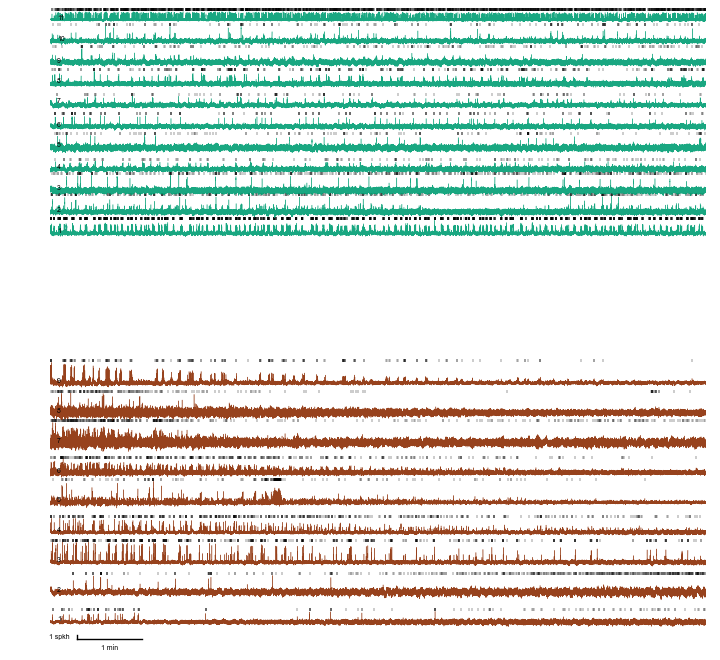

In [10]:
trace_row_offset_1x = 5
trace_row_offset_20x = 7.0
spike_stack_rows = build_spike_stack_rows()

finite_trace_values = []
for row in spike_stack_rows:
    if row is None:
        continue
    finite = row['trace'][np.isfinite(row['trace'])]
    if finite.size:
        finite_trace_values.append(finite)

if finite_trace_values:
    finite_trace_values = np.concatenate(finite_trace_values)
    trace_min = float(np.nanmin(finite_trace_values))
    trace_max = float(np.nanmax(finite_trace_values))
else:
    trace_min = 0.0
    trace_max = 1.0

trace_span = max(1.0, trace_max - trace_min)
inter_group_gap_rows = 2
raster_height = max(0.12, 0.1 * trace_span)
raster_gap = max(0.08, 0.06 * trace_span)
raster_base_offset = trace_max + raster_gap


def add_spike_stack_scale_bars(ax, y_base, horizontal_bar_width_s=60.0):
    x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
    x_right = x_left + horizontal_bar_width_s
    ax.plot([x_left, x_left], [y_base, y_base + 1.0], color='black', linewidth=1.0)
    ax.text(x_left - 0.01 * (time_s[-1] - time_s[0]), y_base + 0.5, '1 spkh', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y_base, y_base], color='black', linewidth=1.0)
    ax.text((x_left + x_right) / 2, y_base - 0.18 * trace_span, '1 min', ha='center', va='top', fontsize=5)


def build_snr_spike_stack_figure(plot_step=1):
    fig, ax = plt.subplots(figsize=(7.2, 0.3 * len(spike_stack_rows)))

    current_offset = 0.0
    max_trace_top = trace_max
    for row in spike_stack_rows:
        if row is None:
            current_offset += inter_group_gap_rows * max(trace_row_offset_1x, trace_row_offset_20x)
            continue

        trace_row_offset = trace_row_offset_1x if row['condition'] == '1x' else trace_row_offset_20x
        aligned_trace = row['trace'] + current_offset
        ax.plot(time_s[::plot_step], aligned_trace[::plot_step], color=row['color'], linewidth=0.3, alpha=0.9)

        if row['spikes'].size:
            displayed_trace_max = np.nanmax(aligned_trace)
            if not np.isfinite(displayed_trace_max):
                displayed_trace_max = current_offset + trace_max
            raster_y0 = displayed_trace_max
            raster_y1 = raster_y0 + raster_height
            ax.vlines(time_s[row['spikes']], raster_y0, raster_y1, color='black', linewidth=0.28)

        label_x = time_s[0] + 0.01 * (time_s[-1] - time_s[0])
        label_idx = np.searchsorted(time_s, label_x)
        local_trace = aligned_trace[max(0, label_idx - 5):min(aligned_trace.size, label_idx + 6)]
        label_y = np.nanmean(local_trace)
        if not np.isfinite(label_y):
            label_y = current_offset + 0.5 * (trace_min + trace_max)
        label_y = np.clip(label_y + 0.08 * trace_span, current_offset + trace_min, current_offset + trace_max)
        ax.text(label_x, label_y, row['label'], ha='left', va='center', fontsize=5)

        max_trace_top = max(max_trace_top, np.nanmax(aligned_trace) if np.any(np.isfinite(aligned_trace)) else current_offset + trace_max)
        current_offset += trace_row_offset

    scale_bar_y = trace_min - raster_gap - 2.1 * raster_height
    add_spike_stack_scale_bars(ax, scale_bar_y)

    y_min = scale_bar_y - 0.25 * trace_span
    y_max = max_trace_top + raster_height + 0.4
    ax.set_xlim(time_s[0], time_s[-1])
    ax.set_ylim(y_min, y_max)
    ax.margins(x=0, y=0)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', left=False, bottom=False, labelleft=False, labelbottom=False)
    fig.subplots_adjust(left=0.07, right=0.98, bottom=0.02, top=0.99)
    return fig

fig = build_snr_spike_stack_figure(plot_step=1)
export_fig = build_snr_spike_stack_figure(plot_step=spike_stack_export_step)
export_fig.savefig(spike_stack_figure_path, format='svg', bbox_inches='tight')
plt.close(export_fig)
print(f'Saved SNR spike stack figure to {spike_stack_figure_path} using trace step {spike_stack_export_step}')
plt.show()



Baseline noise summary range (10 s sliding std with exponential fit) after optional detrending, spike removal, and 40 Hz high-pass: 1x=1.123-4.376, 20x=1.334-6.79
Saved Plotly SNR stacked trace figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_stacked_plotly.html
Saved Matplotlib SNR stacked trace SVG to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_stacked.svg


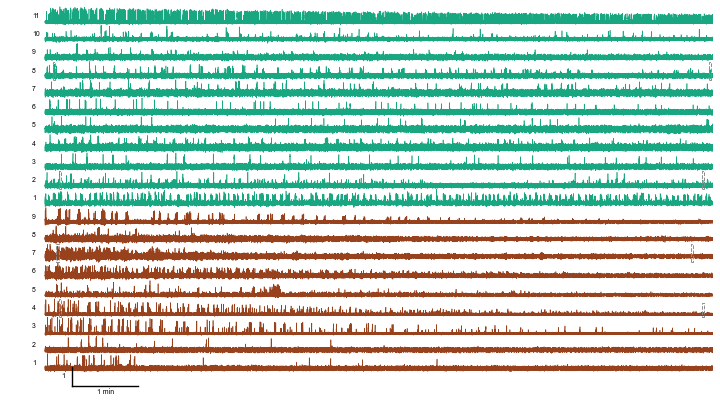

In [23]:
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError as exc:
    raise ImportError('Install plotly in this notebook environment, for example with `pip install plotly`.') from exc

from scipy.ndimage import median_filter as ndi_median_filter, uniform_filter1d as ndi_uniform_filter1d
from scipy.optimize import curve_fit
from scipy.signal import butter, sosfiltfilt

plotly_stacked_snr_figure_path = stacked_normalized_figure_path.with_name(
    'SLM_comparison_snr_stacked_plotly.html'
)

# Controls: y units are fluorescence units divided by baseline noise.
snr_plotly_vertical_offset = 50.0
snr_plotly_trace_step = 1
snr_plotly_line_width = 0.45
snr_plotly_inter_group_gap_rows = inter_group_gap_rows
snr_plotly_fig_height = max(360, int((sum(group_sizes) + snr_plotly_inter_group_gap_rows) * 12))
snr_use_detrended_trace = True
snr_detrend_window_s = 501 / sampling_rate_hz
snr_noise_ignore_edge_s = snr_detrend_window_s
snr_highpass_cutoff_hz = 40.0
snr_highpass_order = 3
snr_use_sliding_exponential_noise = True
snr_sliding_noise_window_s = 10.0
snr_noise_fit_step_s = 1.0
snr_exponential_fit_min_points = 10
snr_spike_removal_pre_ms = 1000.0 / sampling_rate_hz
snr_spike_removal_post_ms = 1000.0 / sampling_rate_hz
snr_scale_bar_height = 6.0
rasterized = False

snr_detrend_window_samples = max(1, int(round(snr_detrend_window_s * sampling_rate_hz)))
if snr_detrend_window_samples % 2 == 0:
    snr_detrend_window_samples += 1
snr_noise_ignore_edge_samples = max(0, int(round(snr_noise_ignore_edge_s * sampling_rate_hz)))
snr_sliding_noise_window_samples = max(3, int(round(snr_sliding_noise_window_s * sampling_rate_hz)))
snr_noise_fit_step_samples = max(1, int(round(snr_noise_fit_step_s * sampling_rate_hz)))

if snr_highpass_cutoff_hz >= 0.5 * sampling_rate_hz:
    raise ValueError(
        f'snr_highpass_cutoff_hz={snr_highpass_cutoff_hz} Hz must be below Nyquist '
        f'({0.5 * sampling_rate_hz:g} Hz).'
    )

snr_highpass_sos = butter(
    snr_highpass_order,
    snr_highpass_cutoff_hz,
    btype='highpass',
    fs=sampling_rate_hz,
    output='sos',
)


def build_sorted_raw_trace_lookup_from_spike_info():
    raw_trace_by_cell_key = {
        condition_label: {
            info['folder']: np.asarray(trace, dtype=float)
            for info, trace in zip(trace_info[condition_label], trace_arrays_by_condition[condition_label])
        }
        for condition_label in ('1x', '20x')
    }
    sorted_raw_lookup = {}
    for condition_label, sorted_info in [
        ('1x', sorted_spike_info_1x),
        ('20x', sorted_spike_info_20x),
    ]:
        sorted_raw_lookup[condition_label] = np.vstack([
            raw_trace_by_cell_key[condition_label][info['folder']]
            for info in sorted_info
        ])
    return sorted_raw_lookup


def interpolate_nonfinite_trace_values(trace):
    trace = np.asarray(trace, dtype=float)
    if np.all(np.isfinite(trace)):
        return trace
    finite_mask = np.isfinite(trace)
    if not finite_mask.any():
        raise ValueError('Cannot interpolate trace because it contains no finite samples.')
    sample_idx = np.arange(trace.size)
    return np.interp(sample_idx, sample_idx[finite_mask], trace[finite_mask])


def detrend_trace_for_snr_normalization(trace):
    trace = interpolate_nonfinite_trace_values(trace)
    if not snr_use_detrended_trace:
        return trace
    subthreshold_trace = ndi_median_filter(trace, size=median_filter_window_samples, mode='reflect')
    slow_trend_trace = ndi_median_filter(subthreshold_trace, size=snr_detrend_window_samples, mode='reflect')
    return trace - slow_trend_trace


def remove_spikes_for_noise_estimate(trace, spike_indices, pre_ms=5.0, post_ms=20.0):
    spike_removed = np.asarray(trace, dtype=float).copy()
    pre_samples = max(0, int(round(pre_ms * sampling_rate_hz / 1000)))
    post_samples = max(1, int(round(post_ms * sampling_rate_hz / 1000)))
    spike_indices = np.asarray(spike_indices, dtype=np.int64)
    spike_indices = spike_indices[(spike_indices >= 0) & (spike_indices < spike_removed.size)]
    for spike_idx in spike_indices:
        start_idx = max(0, int(spike_idx) - pre_samples)
        end_idx = min(spike_removed.size, int(spike_idx) + post_samples + 1)
        spike_removed[start_idx:end_idx] = np.nan
    return interpolate_nonfinite_trace_values(spike_removed)


def compute_sliding_std_trace(trace, window_samples):
    trace = interpolate_nonfinite_trace_values(trace)
    local_mean = ndi_uniform_filter1d(trace, size=window_samples, mode='reflect')
    local_mean_square = ndi_uniform_filter1d(trace * trace, size=window_samples, mode='reflect')
    local_variance = np.maximum(local_mean_square - local_mean * local_mean, 0.0)
    return np.sqrt(local_variance)


def exponential_noise_model(time_s_values, offset, amplitude, tau_s):
    return offset + amplitude * np.exp(-time_s_values / tau_s)


def fit_exponential_noise_baseline(sliding_std_trace):
    sliding_std_trace = np.asarray(sliding_std_trace, dtype=float)
    trace_time_s = np.arange(sliding_std_trace.size, dtype=float) / sampling_rate_hz
    edge_samples = min(snr_noise_ignore_edge_samples, max(0, sliding_std_trace.size // 2 - 1))
    fit_mask = np.isfinite(sliding_std_trace) & (sliding_std_trace > 0)
    if edge_samples:
        fit_mask[:edge_samples] = False
        fit_mask[-edge_samples:] = False
    fit_indices = np.flatnonzero(fit_mask)[::snr_noise_fit_step_samples]
    if fit_indices.size < snr_exponential_fit_min_points:
        fit_indices = np.flatnonzero(fit_mask)
    if fit_indices.size == 0:
        raise ValueError('Cannot fit baseline noise because the sliding std trace has no positive finite samples.')

    fit_time = trace_time_s[fit_indices]
    fit_std = sliding_std_trace[fit_indices]
    min_noise = max(np.finfo(float).eps, 0.01 * float(np.nanmedian(fit_std)))
    duration_s = max(trace_time_s[-1] if trace_time_s.size else 1.0, 1.0 / sampling_rate_hz)
    initial_offset = max(min_noise, float(np.nanpercentile(fit_std, 10)))
    initial_amplitude = max(min_noise, float(np.nanpercentile(fit_std, 90) - initial_offset))
    initial_tau_s = max(snr_sliding_noise_window_s, 0.33 * duration_s)

    try:
        fit_params, _ = curve_fit(
            exponential_noise_model,
            fit_time,
            fit_std,
            p0=(initial_offset, initial_amplitude, initial_tau_s),
            bounds=(
                (min_noise, 0.0, max(1.0 / sampling_rate_hz, snr_sliding_noise_window_s)),
                (max(float(np.nanmax(fit_std)) * 10.0, min_noise * 10.0), max(float(np.nanmax(fit_std)) * 10.0, min_noise * 10.0), max(duration_s * 10.0, snr_sliding_noise_window_s)),
            ),
            maxfev=20000,
        )
        fitted_noise = exponential_noise_model(trace_time_s, *fit_params)
    except (RuntimeError, ValueError):
        fit_params = (float(np.nanmedian(fit_std)), 0.0, initial_tau_s)
        fitted_noise = np.full(sliding_std_trace.size, fit_params[0], dtype=float)

    fitted_noise = np.asarray(fitted_noise, dtype=float)
    fitted_noise[~np.isfinite(fitted_noise) | (fitted_noise <= 0)] = float(np.nanmedian(fit_std))
    fitted_noise = np.maximum(fitted_noise, min_noise)
    return fitted_noise, fit_params


def compute_noise_normalizer_from_spike_removed_trace(trace, spike_indices):
    spike_removed_trace = remove_spikes_for_noise_estimate(
        trace,
        spike_indices,
        pre_ms=snr_spike_removal_pre_ms,
        post_ms=snr_spike_removal_post_ms,
    )
    spike_removed_trace = interpolate_nonfinite_trace_values(spike_removed_trace)
    highpassed_trace = sosfiltfilt(snr_highpass_sos, spike_removed_trace)
    edge_samples = min(snr_noise_ignore_edge_samples, max(0, highpassed_trace.size // 2 - 1))
    noise_trace = highpassed_trace[edge_samples:-edge_samples] if edge_samples else highpassed_trace
    finite_highpassed = noise_trace[np.isfinite(noise_trace)]
    if finite_highpassed.size == 0:
        raise ValueError('Cannot compute baseline noise because high-pass trace has no finite samples.')

    if snr_use_sliding_exponential_noise:
        sliding_std_trace = compute_sliding_std_trace(highpassed_trace, snr_sliding_noise_window_samples)
        noise_normalizer, fit_params = fit_exponential_noise_baseline(sliding_std_trace)
        noise_summary_trace = noise_normalizer[edge_samples:-edge_samples] if edge_samples else noise_normalizer
        baseline_noise_summary = float(np.nanmedian(noise_summary_trace))
        return noise_normalizer, baseline_noise_summary, fit_params

    baseline_noise = float(np.nanstd(finite_highpassed))
    if not np.isfinite(baseline_noise) or baseline_noise <= 0:
        raise ValueError('Cannot compute SNR because baseline noise std is non-positive.')
    return np.full(highpassed_trace.size, baseline_noise, dtype=float), baseline_noise, (baseline_noise, 0.0, np.nan)


def normalize_trace_to_baseline_noise(trace, spike_indices):
    display_trace = detrend_trace_for_snr_normalization(trace)
    noise_normalizer, baseline_noise_summary, noise_fit_params = compute_noise_normalizer_from_spike_removed_trace(display_trace, spike_indices)
    return display_trace / noise_normalizer, baseline_noise_summary, noise_fit_params


def compute_condition_noise_normalized_traces(condition_label):
    sorted_raw_traces = snr_sorted_raw_trace_lookup[condition_label]
    sorted_results = snr_sorted_spike_results_lookup[condition_label]
    normalized_traces = []
    baseline_noises = []
    noise_fit_params = []
    for raw_trace, result in zip(sorted_raw_traces, sorted_results):
        spikes = np.asarray(result['all_spikes'], dtype=np.int64)
        normalized_trace, baseline_noise, fit_params = normalize_trace_to_baseline_noise(raw_trace, spikes)
        normalized_traces.append(normalized_trace)
        baseline_noises.append(baseline_noise)
        noise_fit_params.append(fit_params)
    return np.vstack(normalized_traces), np.asarray(baseline_noises, dtype=float), np.asarray(noise_fit_params, dtype=float)


snr_sorted_raw_trace_lookup = build_sorted_raw_trace_lookup_from_spike_info()
snr_sorted_spike_results_lookup = {
    '1x': sorted_spike_results_1x,
    '20x': sorted_spike_results_20x,
}

snr_traces_1x, baseline_noise_1x, snr_noise_fit_params_1x = compute_condition_noise_normalized_traces('1x')
snr_traces_20x, baseline_noise_20x, snr_noise_fit_params_20x = compute_condition_noise_normalized_traces('20x')
snr_noise_mode_label = (
    f'{snr_sliding_noise_window_s:g} s sliding std with exponential fit'
    if snr_use_sliding_exponential_noise
    else 'whole-trace std'
)
print(
    f'Baseline noise summary range ({snr_noise_mode_label}) after optional detrending, spike removal, and '
    f'{snr_highpass_cutoff_hz:g} Hz high-pass: '
    f'1x={baseline_noise_1x.min():.4g}-{baseline_noise_1x.max():.4g}, '
    f'20x={baseline_noise_20x.min():.4g}-{baseline_noise_20x.max():.4g}'
)

all_snr_values = np.concatenate([snr_traces_1x.ravel(), snr_traces_20x.ravel()])
finite_snr_values = all_snr_values[np.isfinite(all_snr_values)]
if finite_snr_values.size == 0:
    raise ValueError('Cannot plot SNR-normalized traces because no finite SNR values were computed.')
snr_half_range = max(snr_scale_bar_height, float(np.nanpercentile(np.abs(finite_snr_values), 99.5)))
snr_shared_ylim = (-snr_half_range, snr_half_range)

snr_plotly_time_s = time_s[::snr_plotly_trace_step]
snr_plotly_condition_specs = [
    ('1x', snr_traces_1x, COLOR_1X),
    ('20x', snr_traces_20x, COLOR_20X),
]
snr_yaxis_label_prefix = 'Detrended fluorescence' if snr_use_detrended_trace else 'Raw fluorescence'
snr_plotly_group_sizes = [traces.shape[0] for _, traces, _ in snr_plotly_condition_specs]
snr_max_group_size = max(snr_plotly_group_sizes) if snr_plotly_group_sizes else 1
snr_subplot_y_padding = max(2.0, 0.35 * snr_plotly_vertical_offset)
snr_subplot_top_extra = 0.35 * snr_plotly_vertical_offset
snr_x_left_gutter_s = 0.035 * (time_s[-1] - time_s[0])
snr_label_x = time_s[0] - 0.55 * snr_x_left_gutter_s
snr_x_axis_range = [float(time_s[0] - snr_x_left_gutter_s), float(time_s[-1])]
snr_show_condition_labels = False
snr_subplot_y_range = [
    snr_shared_ylim[0] - snr_subplot_y_padding,
    (snr_max_group_size - 1) * snr_plotly_vertical_offset + snr_shared_ylim[1] + snr_subplot_y_padding + snr_subplot_top_extra,
]
snr_plotly_fig_height = max(520, int(snr_max_group_size * 22 * len(snr_plotly_condition_specs)))

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
)
snr_plotly_offset_lookup = {condition_label: {} for condition_label, _, _ in snr_plotly_condition_specs}
snr_plotly_row_lookup = {condition_label: row_idx for row_idx, (condition_label, _, _) in enumerate(snr_plotly_condition_specs, start=1)}
snr_plotly_group_offset_bounds = {}

for subplot_row, (condition_label, snr_traces, color) in enumerate(snr_plotly_condition_specs, start=1):
    n_traces = snr_traces.shape[0]
    group_offsets = []

    for rank, trace in enumerate(snr_traces):
        display_number = rank + 1
        y_offset = rank * snr_plotly_vertical_offset
        group_offsets.append(y_offset)
        snr_plotly_offset_lookup[condition_label][display_number] = y_offset

        plot_trace = np.asarray(trace[::snr_plotly_trace_step], dtype=float)
        fig.add_trace(
            go.Scattergl(
                x=snr_plotly_time_s,
                y=plot_trace + y_offset,
                customdata=plot_trace,
                mode='lines',
                line=dict(color=color, width=snr_plotly_line_width),
                opacity=0.9,
                name=condition_label,
                legendgroup=condition_label,
                showlegend=False,
                hovertemplate=(
                    f'{condition_label} cell {display_number}<br>'
                    'time=%{x:.2f} s<br>'
                    'fluorescence/noise=%{customdata:.2f}<extra></extra>'
                ),
            ),
            row=subplot_row,
            col=1,
        )

        label_x = snr_label_x
        label_idx = np.searchsorted(time_s, label_x)
        label_window = trace[max(0, label_idx - 5):min(trace.size, label_idx + 6)]
        label_y = np.clip(
            np.nanmean(label_window) + 1.5,
            snr_shared_ylim[0] + 1.0,
            snr_shared_ylim[1] - 1.0,
        ) + y_offset
        fig.add_annotation(
            x=label_x,
            y=label_y,
            text=str(display_number),
            showarrow=False,
            xanchor='left',
            yanchor='middle',
            font=dict(size=8, color='black'),
            row=subplot_row,
            col=1,
        )

    snr_plotly_group_offset_bounds[condition_label] = (min(group_offsets), max(group_offsets))

snr_trace_lookup = {
    '1x': snr_traces_1x,
    '20x': snr_traces_20x,
}

for zoom_spec in zoom_specs:
    condition_label = zoom_spec['condition']
    cell_number = int(zoom_spec['cell_number'])
    if cell_number not in snr_plotly_offset_lookup[condition_label]:
        raise ValueError(f"Invalid displayed cell number {cell_number} for condition {condition_label}.")

    trace = snr_trace_lookup[condition_label][cell_number - 1]
    y_offset = snr_plotly_offset_lookup[condition_label][cell_number]
    subplot_row = snr_plotly_row_lookup[condition_label]
    for start_key in ('start_1_s', 'start_2_s'):
        start_s, end_s = clip_zoom_window(zoom_spec[start_key], zoom_duration_s, trace_total_duration_s)
        box_y0, box_y1 = get_trace_segment_box_bounds(trace, start_s, end_s, snr_shared_ylim)
        fig.add_shape(
            type='rect',
            x0=start_s,
            x1=end_s,
            y0=box_y0 + y_offset,
            y1=box_y1 + y_offset,
            line=dict(color='rgba(90, 90, 90, 0.85)', width=0.8, dash='dash'),
            fillcolor='rgba(0, 0, 0, 0)',
            layer='above',
            row=subplot_row,
            col=1,
        )

scale_condition = snr_plotly_condition_specs[-1][0]
scale_cell_number = 1
scale_y_offset = snr_plotly_offset_lookup[scale_condition][scale_cell_number]
scale_subplot_row = snr_plotly_row_lookup[scale_condition]
scale_x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
scale_x_right = scale_x_left + 60.0
scale_y0 = scale_y_offset + snr_shared_ylim[0] + 0.14 * (snr_shared_ylim[1] - snr_shared_ylim[0])
scale_y1 = scale_y0 + snr_scale_bar_height
fig.add_shape(
    type='line',
    x0=scale_x_left,
    x1=scale_x_left,
    y0=scale_y0,
    y1=scale_y1,
    line=dict(color='black', width=1.0),
    row=scale_subplot_row,
    col=1,
)
fig.add_annotation(
    x=scale_x_left - time_s[-1] * 0.01,
    y=(scale_y0 + scale_y1) / 2,
    text=f'SNR={snr_scale_bar_height:g}',
    showarrow=False,
    xanchor='right',
    yanchor='middle',
    font=dict(size=8, color='black'),
    row=scale_subplot_row,
    col=1,
)
fig.add_shape(
    type='line',
    x0=scale_x_left,
    x1=scale_x_right,
    y0=scale_y0,
    y1=scale_y0,
    line=dict(color='black', width=1.0),
    row=scale_subplot_row,
    col=1,
)
fig.add_annotation(
    x=(scale_x_left + scale_x_right) / 2,
    y=scale_y0 - 0.06 * (snr_shared_ylim[1] - snr_shared_ylim[0]),
    text='1 min',
    showarrow=False,
    xanchor='center',
    yanchor='top',
    font=dict(size=8, color='black'),
    row=scale_subplot_row,
    col=1,
)

if snr_show_condition_labels:
    for condition_label, _, color in snr_plotly_condition_specs:
        y_min, y_max = snr_plotly_group_offset_bounds[condition_label]
        fig.add_annotation(
            x=time_s[-1],
            y=(y_min + y_max) / 2,
            text=condition_label,
            showarrow=False,
            xanchor='right',
            yanchor='middle',
            font=dict(size=9, color=color),
            row=snr_plotly_row_lookup[condition_label],
            col=1,
        )

fig.update_layout(
    template='simple_white',
    width=900,
    height=snr_plotly_fig_height,
    margin=dict(l=35, r=20, t=18, b=28),
    hovermode='closest',
)
for subplot_row in range(1, len(snr_plotly_condition_specs) + 1):
    fig.update_yaxes(
        range=snr_subplot_y_range,
        visible=False,
        showgrid=False,
        zeroline=False,
        showticklabels=False,
        ticks='',
        title_text=None,
        row=subplot_row,
        col=1,
    )
    fig.update_xaxes(
        range=snr_x_axis_range,
        visible=False,
        showgrid=False,
        zeroline=False,
        showticklabels=False,
        ticks='',
        title_text=None,
        row=subplot_row,
        col=1,
    )

fig.write_html(plotly_stacked_snr_figure_path, include_plotlyjs='cdn')
print(f'Saved Plotly SNR stacked trace figure to {plotly_stacked_snr_figure_path}')

from matplotlib.patches import Rectangle as MplRectangle

snr_stacked_matplotlib_svg_path = stacked_normalized_figure_path.with_name(
    'SLM_comparison_snr_stacked.svg'
)
snr_matplotlib_trace_offset = 1.0
snr_matplotlib_raster_dpi = 300
snr_matplotlib_condition_specs = [
    spec for condition_order in ('20x', '1x')
    for spec in snr_plotly_condition_specs
    if spec[0] == condition_order
]
snr_matplotlib_group_sizes = [traces.shape[0] for _, traces, _ in snr_matplotlib_condition_specs]
snr_matplotlib_total_traces = sum(snr_matplotlib_group_sizes)
snr_matplotlib_figsize = (7.2, max(4.0, 0.16 * snr_matplotlib_total_traces))
snr_matplotlib_unit_ylim = (0.0, 1.0)


def normalize_trace_minmax_0_to_1(trace):
    trace = np.asarray(trace, dtype=float)
    normalized_trace = np.full_like(trace, np.nan, dtype=float)
    finite_mask = np.isfinite(trace)
    if not finite_mask.any():
        return normalized_trace
    finite_values = trace[finite_mask]
    trace_min = float(np.nanmin(finite_values))
    trace_max = float(np.nanmax(finite_values))
    if not np.isfinite(trace_max - trace_min) or trace_max <= trace_min:
        normalized_trace[finite_mask] = 0.0
    else:
        normalized_trace[finite_mask] = (finite_values - trace_min) / (trace_max - trace_min)
    return normalized_trace


def build_snr_stacked_matplotlib_figure(plot_step=1):
    fig, ax = plt.subplots(figsize=snr_matplotlib_figsize)

    offset_lookup = {condition_label: {} for condition_label, _, _ in snr_matplotlib_condition_specs}
    normalized_trace_lookup = {condition_label: [] for condition_label, _, _ in snr_matplotlib_condition_specs}
    row_idx = 0

    for condition_label, snr_traces, color in snr_matplotlib_condition_specs:
        for rank, trace in enumerate(snr_traces):
            display_number = rank + 1
            y_offset = row_idx * snr_matplotlib_trace_offset
            offset_lookup[condition_label][display_number] = y_offset

            normalized_trace = normalize_trace_minmax_0_to_1(trace)
            normalized_trace_lookup[condition_label].append(normalized_trace)
            plot_trace = np.asarray(normalized_trace[::plot_step], dtype=float)
            ax.plot(
                time_s[::plot_step],
                plot_trace + y_offset,
                color=color,
                linewidth=snr_plotly_line_width,
                alpha=0.9,
                rasterized=rasterized,
            )
            ax.text(snr_label_x, y_offset + 0.5, str(display_number), ha='left', va='center', fontsize=5)
            row_idx += 1

    for zoom_spec in zoom_specs:
        condition_label = zoom_spec['condition']
        cell_number = int(zoom_spec['cell_number'])
        if cell_number not in offset_lookup[condition_label]:
            raise ValueError(f"Invalid displayed cell number {cell_number} for condition {condition_label}.")
        trace = normalized_trace_lookup[condition_label][cell_number - 1]
        y_offset = offset_lookup[condition_label][cell_number]
        for start_key in ('start_1_s', 'start_2_s'):
            start_s, end_s = clip_zoom_window(zoom_spec[start_key], zoom_duration_s, trace_total_duration_s)
            box_y0, box_y1 = get_trace_segment_box_bounds(trace, start_s, end_s, snr_matplotlib_unit_ylim)
            ax.add_patch(
                MplRectangle(
                    (start_s, box_y0 + y_offset),
                    max(0.0, end_s - start_s),
                    box_y1 - box_y0,
                    fill=False,
                    edgecolor='0.55',
                    linewidth=0.7,
                    linestyle='--',
                    clip_on=False,
                    zorder=4,
                )
            )

    scale_x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
    scale_x_right = scale_x_left + 60.0
    scale_y0 = -0.75
    scale_y1 = scale_y0 + 1.0
    ax.plot([scale_x_left, scale_x_left], [scale_y0, scale_y1], color='black', linewidth=1.0, clip_on=False)
    ax.text(
        scale_x_left - time_s[-1] * 0.01,
        (scale_y0 + scale_y1) / 2,
        '1',
        ha='right',
        va='center',
        fontsize=5,
    )
    ax.plot([scale_x_left, scale_x_right], [scale_y0, scale_y0], color='black', linewidth=1.0, clip_on=False)
    ax.text(
        (scale_x_left + scale_x_right) / 2,
        scale_y0 - 0.18,
        '1 min',
        ha='center',
        va='top',
        fontsize=5,
    )

    y_min = scale_y0 - 0.35
    y_max = max(1.0, (snr_matplotlib_total_traces - 1) * snr_matplotlib_trace_offset + 1.15)
    ax.set_xlim(snr_x_axis_range)
    ax.set_ylim(y_min, y_max)
    ax.margins(x=0, y=0)
    ax.axis('off')
    fig.subplots_adjust(left=0.03, right=0.99, bottom=0.02, top=0.99)
    return fig

snr_matplotlib_fig = build_snr_stacked_matplotlib_figure(plot_step=1)
snr_matplotlib_export_fig = build_snr_stacked_matplotlib_figure(plot_step=snr_plotly_trace_step)
snr_matplotlib_export_fig.savefig(
    snr_stacked_matplotlib_svg_path,
    format='svg',
    bbox_inches='tight',
    dpi=snr_matplotlib_raster_dpi,
)
plt.close(snr_matplotlib_export_fig)
print(f'Saved Matplotlib SNR stacked trace SVG to {snr_stacked_matplotlib_svg_path}')
plt.show()



Saved selected SNR trace SVG to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_selected_traces.svg


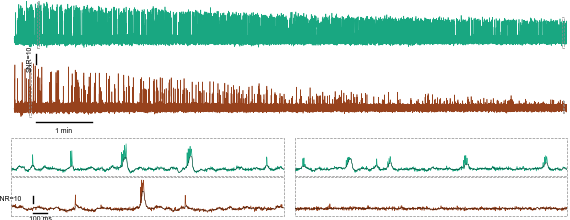

In [30]:
from matplotlib.patches import Rectangle as MplRectangle

selected_snr_trace_svg_path = stacked_normalized_figure_path.with_name(
    'SLM_comparison_snr_selected_traces.svg'
)

selected_snr_trace_specs = [
    {'condition': '1x', 'cell_number': 11},
    {'condition': '20x', 'cell_number': 4},
]
selected_snr_zoom_duration_s = 2
# One zoom spec per selected trace, in the same order as selected_snr_trace_specs.
selected_snr_zoom_specs = [
    {'start_1_s': 24.65, 'start_2_s': 594.9},
    {'start_1_s': 16.19, 'start_2_s': 595},
]
if len(selected_snr_zoom_specs) != len(selected_snr_trace_specs):
    raise ValueError('selected_snr_zoom_specs must have one entry per selected_snr_trace_specs entry.')

selected_snr_trace_step = 1
selected_snr_trace_offset = 65.0
selected_snr_scale_bar_height = 10.0
selected_snr_scale_bar_time_s = 60.0
selected_snr_zoom_scale_bar_time_s = 0.1
selected_snr_line_width = 0.45
selected_snr_zoom_line_width = 0.45
selected_snr_subthreshold_color = 'black'
selected_snr_subthreshold_line_width = 0.25
selected_snr_subthreshold_median_window_samples = 11
selected_snr_subthreshold_delete_before_samples = 1
selected_snr_subthreshold_delete_after_samples = 1
selected_snr_figsize = (5.7, 2.2)
selected_snr_full_x_left_margin_fraction = 0.005
selected_snr_full_trace_order = ['20x', '1x']
selected_snr_zoom_row_order = ['1x', '20x']

selected_snr_color_lookup = {
    condition_label: color
    for condition_label, _, color in snr_plotly_condition_specs
}


def compute_selected_subthreshold_snr_trace(condition_label, cell_number):
    trace = np.asarray(snr_trace_lookup[condition_label][cell_number - 1], dtype=float).copy()
    spike_result = snr_sorted_spike_results_lookup[condition_label][cell_number - 1]
    spike_indices = np.asarray(spike_result['all_spikes'], dtype=np.int64)
    spike_indices = spike_indices[(spike_indices >= 0) & (spike_indices < trace.size)]

    for spike_idx in spike_indices:
        start_idx = max(0, int(spike_idx) - selected_snr_subthreshold_delete_before_samples)
        end_idx = min(trace.size, int(spike_idx) + selected_snr_subthreshold_delete_after_samples + 1)
        trace[start_idx:end_idx] = np.nan

    trace = interpolate_nonfinite_trace_values(trace)
    return medfilt(trace, kernel_size=selected_snr_subthreshold_median_window_samples)


selected_snr_traces = []
for plot_idx, (trace_spec, zoom_spec) in enumerate(zip(selected_snr_trace_specs, selected_snr_zoom_specs)):
    condition_label = trace_spec['condition']
    cell_number = int(trace_spec['cell_number'])
    if condition_label not in snr_trace_lookup:
        raise ValueError(f"Invalid condition {condition_label!r}. Valid conditions are {list(snr_trace_lookup)}.")
    condition_traces = snr_trace_lookup[condition_label]
    if not 1 <= cell_number <= condition_traces.shape[0]:
        raise ValueError(
            f"Invalid displayed cell number {cell_number} for condition {condition_label}. "
            f"Valid range is 1-{condition_traces.shape[0]}."
        )
    selected_snr_traces.append({
        'condition': condition_label,
        'cell_number': cell_number,
        'trace': np.asarray(condition_traces[cell_number - 1], dtype=float),
        'subthreshold_trace': compute_selected_subthreshold_snr_trace(condition_label, cell_number),
        'color': selected_snr_color_lookup[condition_label],
        'offset': 0.0,
        'zoom_spec': zoom_spec,
    })

selected_snr_trace_by_condition = {
    trace_info_selected['condition']: trace_info_selected
    for trace_info_selected in selected_snr_traces
}
missing_zoom_rows = [
    condition_label
    for condition_label in selected_snr_zoom_row_order
    if condition_label not in selected_snr_trace_by_condition
]
if missing_zoom_rows:
    raise ValueError(f"Selected traces must include these zoom rows: {missing_zoom_rows}.")

selected_snr_full_trace_ordered_traces = [
    selected_snr_trace_by_condition[condition_label]
    for condition_label in selected_snr_full_trace_order
    if condition_label in selected_snr_trace_by_condition
]
for plot_idx, trace_info_selected in enumerate(selected_snr_full_trace_ordered_traces):
    trace_info_selected['offset'] = plot_idx * selected_snr_trace_offset

selected_zoom_segments = []
for condition_label in selected_snr_zoom_row_order:
    trace_info_selected = selected_snr_trace_by_condition[condition_label]
    trace = trace_info_selected['trace']
    subthreshold_trace = trace_info_selected['subthreshold_trace']
    for start_key in ('start_1_s', 'start_2_s'):
        start_s, end_s = clip_zoom_window(
            trace_info_selected['zoom_spec'][start_key],
            selected_snr_zoom_duration_s,
            trace_total_duration_s,
        )
        start_idx = int(round(start_s * sampling_rate_hz))
        end_idx = max(start_idx + 1, int(round(end_s * sampling_rate_hz)))
        end_idx = min(trace.size, end_idx)
        segment = np.asarray(trace[start_idx:end_idx], dtype=float)
        subthreshold_segment = np.asarray(subthreshold_trace[start_idx:end_idx], dtype=float)
        segment_time_s = np.arange(segment.size, dtype=float) / sampling_rate_hz
        selected_zoom_segments.append({
            'condition': condition_label,
            'cell_number': trace_info_selected['cell_number'],
            'start_key': start_key,
            'segment_time_s': segment_time_s,
            'segment': segment,
            'subthreshold_segment': subthreshold_segment,
            'color': trace_info_selected['color'],
        })

finite_zoom_values = []
for segment_info in selected_zoom_segments:
    for value_key in ('segment', 'subthreshold_segment'):
        finite_values = segment_info[value_key][np.isfinite(segment_info[value_key])]
        if finite_values.size:
            finite_zoom_values.append(finite_values)
if finite_zoom_values:
    finite_zoom_values = np.concatenate(finite_zoom_values)
    zoom_y_min = float(np.nanmin(finite_zoom_values))
    zoom_y_max = float(np.nanmax(finite_zoom_values))
else:
    zoom_y_min = -selected_snr_scale_bar_height
    zoom_y_max = selected_snr_scale_bar_height
zoom_y_span = max(selected_snr_scale_bar_height, zoom_y_max - zoom_y_min)
selected_snr_zoom_ylim = (
    zoom_y_min - 0.08 * zoom_y_span,
    zoom_y_max + 0.08 * zoom_y_span,
)

fig = plt.figure(figsize=selected_snr_figsize)
grid = fig.add_gridspec(
    3,
    2,
    height_ratios=[3.0, 0.85, 0.85],
    hspace=0.02,
    wspace=0.04,
)
ax_full = fig.add_subplot(grid[0, :])
zoom_axes = {
    ('1x', 'start_1_s'): fig.add_subplot(grid[1, 0]),
    ('1x', 'start_2_s'): fig.add_subplot(grid[1, 1]),
    ('20x', 'start_1_s'): fig.add_subplot(grid[2, 0]),
    ('20x', 'start_2_s'): fig.add_subplot(grid[2, 1]),
}

finite_aligned_values = []
for trace_info_selected in selected_snr_full_trace_ordered_traces:
    trace = trace_info_selected['trace']
    offset = trace_info_selected['offset']
    finite = trace[np.isfinite(trace)] + offset
    if finite.size:
        finite_aligned_values.append(finite)
    ax_full.plot(
        time_s[::selected_snr_trace_step],
        trace[::selected_snr_trace_step] + offset,
        color=trace_info_selected['color'],
        linewidth=selected_snr_line_width,
        alpha=0.9,
        zorder=1,
    )
for trace_info_selected in selected_snr_full_trace_ordered_traces:
    trace = trace_info_selected['trace']
    trace_finite = trace[np.isfinite(trace)]
    trace_limits = (
        float(np.nanmin(trace_finite)) if trace_finite.size else -selected_snr_scale_bar_height,
        float(np.nanmax(trace_finite)) if trace_finite.size else selected_snr_scale_bar_height,
    )
    offset = trace_info_selected['offset']
    for start_key in ('start_1_s', 'start_2_s'):
        start_s, end_s = clip_zoom_window(
            trace_info_selected['zoom_spec'][start_key],
            selected_snr_zoom_duration_s,
            trace_total_duration_s,
        )
        box_y0, box_y1 = get_trace_segment_box_bounds(trace, start_s, end_s, trace_limits)
        ax_full.add_patch(
            MplRectangle(
                (start_s, box_y0 + offset),
                max(0.0, end_s - start_s),
                box_y1 - box_y0,
                fill=False,
                edgecolor='0.55',
                linewidth=0.5,
                linestyle='--',
                clip_on=False,
                zorder=4,
            )
        )

for segment_info in selected_zoom_segments:
    ax_zoom = zoom_axes[(segment_info['condition'], segment_info['start_key'])]
    ax_zoom.plot(
        segment_info['segment_time_s'],
        segment_info['segment'],
        color=segment_info['color'],
        linewidth=selected_snr_zoom_line_width,
        alpha=0.9,
        zorder=1,
    )
    ax_zoom.plot(
        segment_info['segment_time_s'],
        segment_info['subthreshold_segment'],
        color=selected_snr_subthreshold_color,
        linewidth=selected_snr_subthreshold_line_width,
        alpha=0.95,
        zorder=3,
    )
    zoom_xlim = (0.0, max(selected_snr_zoom_duration_s, 1.0 / sampling_rate_hz))
    ax_zoom.set_xlim(zoom_xlim)
    ax_zoom.set_ylim(selected_snr_zoom_ylim)
    ax_zoom.add_patch(
        MplRectangle(
            (zoom_xlim[0], selected_snr_zoom_ylim[0]),
            zoom_xlim[1] - zoom_xlim[0],
            selected_snr_zoom_ylim[1] - selected_snr_zoom_ylim[0],
            fill=False,
            edgecolor='0.55',
            linewidth=0.5,
            linestyle='--',
            clip_on=False,
            zorder=4,
        )
    )
    ax_zoom.margins(x=0, y=0)
    ax_zoom.axis('off')

if finite_aligned_values:
    finite_aligned_values = np.concatenate(finite_aligned_values)
    trace_y_min = float(np.nanmin(finite_aligned_values))
    trace_y_max = float(np.nanmax(finite_aligned_values))
else:
    trace_y_min = -selected_snr_scale_bar_height
    trace_y_max = selected_snr_trace_offset + selected_snr_scale_bar_height
trace_y_span = max(selected_snr_scale_bar_height, trace_y_max - trace_y_min)

scale_x_left = time_s[0] + 0.04 * (time_s[-1] - time_s[0])
scale_x_right = scale_x_left + selected_snr_scale_bar_time_s
trace_20x_info = selected_snr_trace_by_condition['20x']
trace_20x = trace_20x_info['trace']
trace_20x_finite = trace_20x[np.isfinite(trace_20x)]
trace_20x_bottom = (
    float(np.nanmin(trace_20x_finite)) + trace_20x_info['offset']
    if trace_20x_finite.size
    else trace_20x_info['offset']
)
horizontal_scale_y = trace_20x_bottom - 0.05 * trace_y_span
vertical_scale_x = scale_x_left
vertical_scale_y0 = 0.5 * (trace_y_min + trace_y_max - selected_snr_scale_bar_height)
vertical_scale_y1 = vertical_scale_y0 + selected_snr_scale_bar_height
ax_full.plot([vertical_scale_x, vertical_scale_x], [vertical_scale_y0, vertical_scale_y1], color='black', linewidth=1.0, clip_on=False)
ax_full.text(
    vertical_scale_x - 0.012 * (time_s[-1] - time_s[0]),
    0.5 * (vertical_scale_y0 + vertical_scale_y1),
    f'SNR={selected_snr_scale_bar_height:g}',
    ha='center',
    va='center',
    rotation=90,
    fontsize=5,
)
ax_full.plot([scale_x_left, scale_x_right], [horizontal_scale_y, horizontal_scale_y], color='black', linewidth=1.0, clip_on=False)
ax_full.text(
    (scale_x_left + scale_x_right) / 2,
    horizontal_scale_y - 0.05 * trace_y_span,
    '1 min',
    ha='center',
    va='top',
    fontsize=5,
)
full_y_min = min(trace_y_min, horizontal_scale_y - 0.12 * trace_y_span, vertical_scale_y0 - 0.08 * trace_y_span)
full_y_max = max(trace_y_max, vertical_scale_y1 + 0.08 * trace_y_span)

zoom_scale_ax = zoom_axes[('20x', 'start_1_s')]
zoom_scale_x_left = 0.08 * selected_snr_zoom_duration_s
zoom_scale_x_right = min(selected_snr_zoom_duration_s, zoom_scale_x_left + selected_snr_zoom_scale_bar_time_s)
zoom_y_range = selected_snr_zoom_ylim[1] - selected_snr_zoom_ylim[0]
zoom_horizontal_scale_y = selected_snr_zoom_ylim[0] + 0.08 * zoom_y_range
zoom_vertical_scale_y0 = selected_snr_zoom_ylim[0] + 0.32 * zoom_y_range
zoom_vertical_scale_y1 = zoom_vertical_scale_y0 + selected_snr_scale_bar_height
zoom_scale_ax.plot([zoom_scale_x_left, zoom_scale_x_left], [zoom_vertical_scale_y0, zoom_vertical_scale_y1], color='black', linewidth=1.0, clip_on=False)
zoom_scale_ax.text(
    zoom_scale_x_left - 0.04 * selected_snr_zoom_duration_s,
    (zoom_vertical_scale_y0 + zoom_vertical_scale_y1) / 2,
    f'SNR={selected_snr_scale_bar_height:g}',
    ha='right',
    va='center',
    fontsize=5,
)
zoom_scale_ax.plot([zoom_scale_x_left, zoom_scale_x_right], [zoom_horizontal_scale_y, zoom_horizontal_scale_y], color='black', linewidth=1.0, clip_on=False)
zoom_scale_ax.text(
    (zoom_scale_x_left + zoom_scale_x_right) / 2,
    zoom_horizontal_scale_y - 0.08 * zoom_y_range,
    '100 ms',
    ha='center',
    va='top',
    fontsize=5,
)

ax_full.set_xlim(
    time_s[0] - selected_snr_full_x_left_margin_fraction * (time_s[-1] - time_s[0]),
    time_s[-1],
)
ax_full.set_ylim(full_y_min, full_y_max)
ax_full.margins(x=0, y=0)
ax_full.axis('off')
fig.subplots_adjust(left=0.02, right=0.995, bottom=0.02, top=0.995)
fig.savefig(selected_snr_trace_svg_path, format='svg', bbox_inches='tight')
print(f'Saved selected SNR trace SVG to {selected_snr_trace_svg_path}')


Saved zoomed SNR trace stack figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_spike_stacked_first_last30s.svg


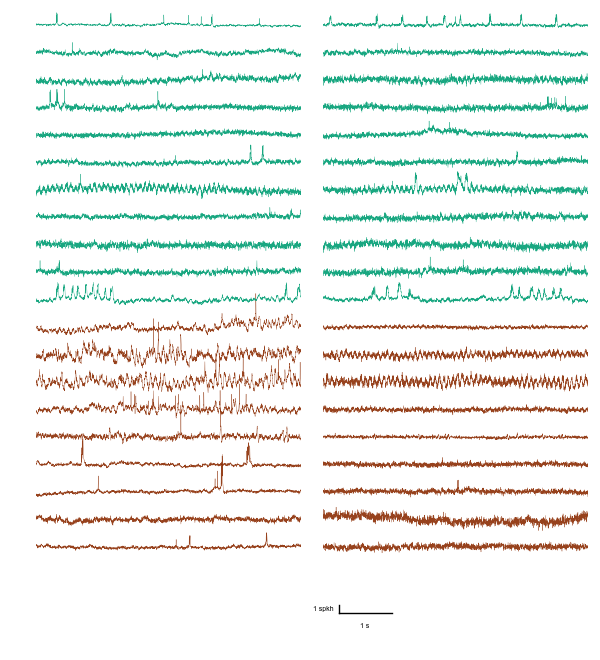

In [13]:
spike_stack_zoom_figure_path = spike_stack_figure_path.with_name(f'{spike_stack_figure_path.stem}_first_last30s.svg')
zoom_window_seconds = 5.0
zoom_trace_row_offset_1x = 3.5
zoom_trace_row_offset_20x = 3.5
zoom_inter_group_gap_rows = 0
zoom_spike_stack_figsize = (6, 0.3 * len(spike_stack_rows))


def compute_zoom_trace_rows():
    rows = []
    current_offset = 0.0
    min_trace_bottom = trace_min
    max_trace_top = trace_max

    for row in spike_stack_rows:
        if row is None:
            current_offset += zoom_inter_group_gap_rows * max(zoom_trace_row_offset_1x, zoom_trace_row_offset_20x)
            continue

        trace_row_offset = zoom_trace_row_offset_1x if row['condition'] == '1x' else zoom_trace_row_offset_20x
        aligned_trace = row['trace'] + current_offset
        rows.append({**row, 'aligned_trace': aligned_trace})
        if np.any(np.isfinite(aligned_trace)):
            min_trace_bottom = min(min_trace_bottom, float(np.nanmin(aligned_trace)))
            max_trace_top = max(max_trace_top, float(np.nanmax(aligned_trace)))
        current_offset += trace_row_offset

    return rows, min_trace_bottom, max_trace_top


def add_zoom_trace_scale_bars(ax, x_limits, y_base, horizontal_bar_width_s=1.0):
    x_left = x_limits[0] + 0.06 * (x_limits[1] - x_limits[0])
    x_right = min(x_limits[1], x_left + horizontal_bar_width_s)
    ax.plot([x_left, x_left], [y_base, y_base + 1.0], color='black', linewidth=1.0)
    ax.text(x_left - 0.02 * (x_limits[1] - x_limits[0]), y_base + 0.5, '1 spkh', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y_base, y_base], color='black', linewidth=1.0)
    ax.text((x_left + x_right) / 2, y_base - 0.18 * trace_span, '1 s', ha='center', va='top', fontsize=5)


def build_zoomed_snr_trace_stack_figure(x_limits_left, x_limits_right, plot_step=1):
    fig, axes = plt.subplots(1, 2, figsize=zoom_spike_stack_figsize, sharey=True)
    zoom_rows, min_trace_bottom, max_trace_top = compute_zoom_trace_rows()
    y_base = min_trace_bottom - 0.9 * trace_span
    y_min = y_base - 0.25 * trace_span
    y_max = max_trace_top + 0.4
    x_limits_by_axis = [x_limits_left, x_limits_right]

    for ax, x_limits in zip(axes, x_limits_by_axis):
        for row in zoom_rows:
            ax.plot(time_s[::plot_step], row['aligned_trace'][::plot_step], color=row['color'], linewidth=0.25, alpha=0.9)

        ax.set_xlim(*x_limits)
        ax.set_ylim(y_min, y_max)
        ax.margins(x=0, y=0)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='both', left=False, bottom=False, labelleft=False, labelbottom=False)

    add_zoom_trace_scale_bars(axes[1], x_limits_right, y_base)
    fig.subplots_adjust(left=0.06, right=0.98, bottom=0.05, top=0.99, wspace=0.08)
    return fig


recording_end_s = 598
left_window_start_s = 7.8
right_window_start_s = max(0.0, recording_end_s - zoom_window_seconds)
left_window_limits = (left_window_start_s, min(left_window_start_s + zoom_window_seconds, recording_end_s))
right_window_limits = (right_window_start_s, min(right_window_start_s + zoom_window_seconds, recording_end_s))

fig = build_zoomed_snr_trace_stack_figure(left_window_limits, right_window_limits, plot_step=1)
fig.savefig(spike_stack_zoom_figure_path, format='svg', bbox_inches='tight')
print(f'Saved zoomed SNR trace stack figure to {spike_stack_zoom_figure_path}')
plt.show()



Saved selected-cell SNR-normalized zoom figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_snr_spike_stacked_snr_normalized_selected_zoom_panels.svg


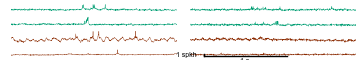

In [14]:
spike_stack_snr_normalized_zoom_figure_path = spike_stack_figure_path.with_name(f'{spike_stack_figure_path.stem}_snr_normalized_selected_zoom_panels.svg')
snr_zoom_panel_figsize = [3.6, 0.6]
snr_zoom_panel_scale_bar_time_s = 1.0
snr_zoom_panel_scale_bar_height = 1.0
snr_trace_lookup = {
    '1x': sorted_spike_results_1x,
    '20x': sorted_spike_results_20x,
}

def get_snr_normalized_trace_by_display_number(condition_label, cell_number):
    sorted_results = snr_trace_lookup[condition_label]
    if not 1 <= int(cell_number) <= len(sorted_results):
        raise ValueError(
            f"Invalid displayed cell number {cell_number} for condition {condition_label}. "
            f"Valid range is 1-{len(sorted_results)}."
        )
    return np.asarray(sorted_results[int(cell_number) - 1]['trace_SNR_interpolated'], dtype=float)

def extract_snr_zoom_segment(trace, start_s, duration_s):
    clipped_start_s, clipped_end_s = clip_zoom_window(start_s, duration_s, trace.size / sampling_rate_hz)
    start_idx = int(round(clipped_start_s * sampling_rate_hz))
    end_idx = max(start_idx + 1, int(round(clipped_end_s * sampling_rate_hz)))
    end_idx = min(trace.size, end_idx)
    segment = trace[start_idx:end_idx]
    segment_time_s = np.arange(segment.size, dtype=float) / sampling_rate_hz
    return segment_time_s, segment

snr_zoom_segments = []
for zoom_spec in zoom_specs:
    snr_trace = get_snr_normalized_trace_by_display_number(zoom_spec['condition'], zoom_spec['cell_number'])
    segment_time_1_s, segment_1 = extract_snr_zoom_segment(snr_trace, zoom_spec['start_1_s'], zoom_duration_s)
    segment_time_2_s, segment_2 = extract_snr_zoom_segment(snr_trace, zoom_spec['start_2_s'], zoom_duration_s)
    snr_zoom_segments.append({
        'condition': zoom_spec['condition'],
        'cell_number': zoom_spec['cell_number'],
        'segment_time_1_s': segment_time_1_s,
        'segment_1': segment_1,
        'segment_time_2_s': segment_time_2_s,
        'segment_2': segment_2,
    })

all_snr_zoom_values = np.concatenate([
    np.concatenate([segment_spec['segment_1'], segment_spec['segment_2']])
    for segment_spec in snr_zoom_segments
])
snr_zoom_y_min = float(np.nanmin(all_snr_zoom_values))
snr_zoom_y_max = float(np.nanmax(all_snr_zoom_values))
snr_zoom_y_range = snr_zoom_y_max - snr_zoom_y_min if snr_zoom_y_max > snr_zoom_y_min else max(1.0, abs(snr_zoom_y_max) * 0.2 + 1.0)
snr_zoom_shared_ylim = (snr_zoom_y_min - 0.05 * snr_zoom_y_range, snr_zoom_y_max + 0.05 * snr_zoom_y_range)

def add_snr_zoom_panel_scale_bars(ax, x_limits, y_limits, horizontal_bar_width_s=1.0, vertical_bar_height=1.0):
    x_left = x_limits[0] + 0.08 * (x_limits[1] - x_limits[0])
    x_right = min(x_limits[1], x_left + horizontal_bar_width_s)
    y0 = y_limits[0] + 0.14 * (y_limits[1] - y_limits[0])
    ax.plot([x_left, x_left], [y0, y0 + vertical_bar_height], color='black', linewidth=1.0, clip_on=False)
    ax.text(x_left - 0.04 * (x_limits[1] - x_limits[0]), y0 + vertical_bar_height / 2, '1 spkh', ha='right', va='center', fontsize=5)
    ax.plot([x_left, x_right], [y0, y0], color='black', linewidth=1.0, clip_on=False)
    ax.text((x_left + x_right) / 2, y0 - 0.10 * (y_limits[1] - y_limits[0]), '1 s', ha='center', va='top', fontsize=5)

fig, axes = plt.subplots(len(zoom_specs), 2, figsize=snr_zoom_panel_figsize, sharey=True)
for row_idx, segment_spec in enumerate(snr_zoom_segments):
    color = COLOR_1X if segment_spec['condition'] == '1x' else COLOR_20X
    axes[row_idx, 0].plot(segment_spec['segment_time_1_s'], segment_spec['segment_1'], color=color, linewidth=0.25)
    axes[row_idx, 1].plot(segment_spec['segment_time_2_s'], segment_spec['segment_2'], color=color, linewidth=0.25)
    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        ax.set_ylim(snr_zoom_shared_ylim)
        ax.set_xlim(0.0, max(zoom_duration_s, 1.0 / sampling_rate_hz))
        ax.margins(x=0, y=0)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='both', left=False, bottom=False, labelleft=False, labelbottom=False)

add_snr_zoom_panel_scale_bars(
    axes[-1, -1],
    (0.0, max(zoom_duration_s, 1.0 / sampling_rate_hz)),
    snr_zoom_shared_ylim,
    horizontal_bar_width_s=snr_zoom_panel_scale_bar_time_s,
    vertical_bar_height=snr_zoom_panel_scale_bar_height,
)

fig.subplots_adjust(left=0.03, right=0.99, bottom=0.03, top=0.99, wspace=0.08, hspace=0.18)
fig.savefig(spike_stack_snr_normalized_zoom_figure_path, format='svg', bbox_inches='tight')
print(f'Saved selected-cell SNR-normalized zoom figure to {spike_stack_snr_normalized_zoom_figure_path}')
plt.show()


# Recalculate SNR and compare SNR decay

Recalculating SNR for 1x...
  1x cell 1/11
  1x cell 2/11
  1x cell 3/11
  1x cell 4/11
  1x cell 5/11
  1x cell 6/11
  1x cell 7/11
  1x cell 8/11
  1x cell 9/11
  1x cell 10/11
  1x cell 11/11
Recalculating SNR for 20x...
  20x cell 1/9
  20x cell 2/9
  20x cell 3/9
  20x cell 4/9
  20x cell 5/9
  20x cell 6/9
  20x cell 7/9
  20x cell 8/9
  20x cell 9/9
1x recalculated SNR mapping:
  1: pAce21_BR_cell2_1x | real 3.59->3.36 (-6.49%) | fitted 3.95->3.38 (-14.61%, -1.46%/min, summary -1.54%/min, last spike 599.99s)
  2: pAce21_BR_cell3_1x | real 5.36->4.15 (-22.42%) | fitted 6.05->4.31 (-28.76%, -2.88%/min, summary -3.03%/min, last spike 597.67s)
  3: pAce21_BR_cell5_1x | real 2.81->2.90 (3.15%) | fitted 3.32->3.15 (-5.07%, -0.51%/min, summary -0.53%/min, last spike 599.66s)
  4: pAce21_PR_cell2_1x | real 7.92->5.28 (-33.38%) | fitted 6.91->4.67 (-32.50%, -3.25%/min, summary -3.42%/min, last spike 594.41s)
  5: pAce21_PR_cell3_1x | real 4.04->3.13 (-22.60%) | fitted 3.59->3.36 (-6.20%,

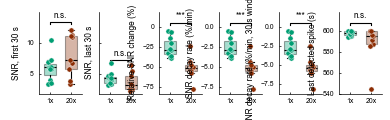

In [15]:
snr_fit_window_seconds = 10.0
snr_summary_window_seconds = 30.0
snr_summary_window_samples = int(round(snr_summary_window_seconds * sampling_rate_hz))
recalculated_snr_figsize = (3.9, 1.2)
recalculated_snr_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_comparison_recalculated_snr_summary.svg')

def compute_measured_window_snr(snr_result, window_seconds=10.0):
    selected_spikes = np.asarray(snr_result['selected_spikes_for_height'], dtype=int)
    selected_heights = np.asarray(snr_result['selected_spike_heights'], dtype=float)
    baseline_std = np.asarray(snr_result['baseline_std'], dtype=float)
    fs = float(snr_result['sampling_rate_hz'])
    n_samples = len(np.asarray(snr_result['time_seconds'], dtype=float))
    window_samples = max(1, int(round(window_seconds * fs)))
    measured_window_snr = np.full(baseline_std.shape, np.nan, dtype=float)

    valid_height_mask = np.isfinite(selected_heights)
    selected_spikes = selected_spikes[valid_height_mask]
    selected_heights = selected_heights[valid_height_mask]

    for window_idx, baseline_value in enumerate(baseline_std):
        if not np.isfinite(baseline_value) or baseline_value <= 0:
            continue
        start = window_idx * window_samples
        end = min(n_samples, start + window_samples)
        in_window = (selected_spikes >= start) & (selected_spikes < end)
        if not np.any(in_window):
            continue
        median_height = np.nanmedian(selected_heights[in_window])
        if np.isfinite(median_height):
            measured_window_snr[window_idx] = median_height / baseline_value
    return measured_window_snr

def summarize_recalculated_snr(cell_result):
    with contextlib.redirect_stdout(io.StringIO()):
        snr_result = compute_time_varying_snr_from_trace(
            trace=cell_result['trace_SNR_interpolated'],
            spks=cell_result['all_spikes'],
            complex_burst_dict=cell_result['complex_bursts_dict'],
            sampling_rate_hz=sampling_rate_hz,
            isi_threshold_ms=20,
            spike_baseline_points=3,
            spike_remove_points=3,
            baseline_window_seconds=snr_fit_window_seconds,
            plot_single_cell=False,
        )

    detected_spikes = np.asarray(cell_result['all_spikes'], dtype=int).reshape(-1)
    has_detected_spikes = detected_spikes.size > 0
    last_detected_spike_time_s = (float(np.nanmax(detected_spikes)) / sampling_rate_hz) if has_detected_spikes else np.nan

    measured_window_snr = compute_measured_window_snr(
        snr_result,
        window_seconds=snr_fit_window_seconds,
    )
    fit_window_starts_s = np.arange(measured_window_snr.size, dtype=float) * snr_fit_window_seconds
    fit_window_ends_s = fit_window_starts_s + snr_fit_window_seconds
    total_duration_s = len(cell_result['trace_SNR_interpolated']) / sampling_rate_hz
    initial_real_mask = fit_window_starts_s < snr_summary_window_seconds
    end_real_mask = fit_window_ends_s > max(0.0, total_duration_s - snr_summary_window_seconds)
    initial_real_window = measured_window_snr[initial_real_mask]
    end_real_window = measured_window_snr[end_real_mask]
    initial_real_snr = np.nanmean(initial_real_window) if np.any(np.isfinite(initial_real_window)) else np.nan
    end_real_snr = np.nanmean(end_real_window) if np.any(np.isfinite(end_real_window)) else np.nan

    fitted_snr = np.asarray(snr_result['snr_time_varying'], dtype=float)
    fitted_initial_window = fitted_snr[:snr_summary_window_samples]
    fitted_end_window = fitted_snr[-snr_summary_window_samples:]
    initial_fitted_snr = np.nanmean(fitted_initial_window) if np.any(np.isfinite(fitted_initial_window)) else np.nan
    end_fitted_snr = np.nanmean(fitted_end_window) if np.any(np.isfinite(fitted_end_window)) else np.nan

    def _drop_pct(initial_value, end_value):
        if not np.isfinite(initial_value) or not np.isfinite(end_value) or initial_value <= 0:
            return np.nan
        return (end_value - initial_value) / initial_value * 100.0

    def _drop_rate_pct_per_min(initial_value, end_value, total_duration_seconds):
        drop_pct = _drop_pct(initial_value, end_value)
        total_duration_min = total_duration_seconds / 60.0
        if not np.isfinite(drop_pct) or total_duration_min <= 0:
            return np.nan
        return drop_pct / total_duration_min

    def _summary_window_drop_rate_pct_per_min(initial_value, end_value, total_duration_seconds):
        drop_pct = _drop_pct(initial_value, end_value)
        summary_interval_min = (total_duration_seconds - snr_summary_window_seconds) / 60.0
        if not np.isfinite(drop_pct) or summary_interval_min <= 0:
            return np.nan
        return drop_pct / summary_interval_min

    return {
        'has_detected_spikes': bool(has_detected_spikes),
        'last_detected_spike_time_s': last_detected_spike_time_s,
        'snr_result': snr_result,
        'measured_window_snr': measured_window_snr,
        'initial_real_snr': initial_real_snr,
        'end_real_snr': end_real_snr,
        'drop_real_pct': _drop_pct(initial_real_snr, end_real_snr),
        'drop_real_rate_pct_per_min': _drop_rate_pct_per_min(initial_real_snr, end_real_snr, total_duration_s),
        'initial_fitted_snr': initial_fitted_snr,
        'end_fitted_snr': end_fitted_snr,
        'drop_fitted_pct': _drop_pct(initial_fitted_snr, end_fitted_snr),
        'drop_fitted_rate_pct_per_min': _drop_rate_pct_per_min(initial_fitted_snr, end_fitted_snr, total_duration_s),
        'drop_fitted_summary_rate_pct_per_min': _summary_window_drop_rate_pct_per_min(initial_fitted_snr, end_fitted_snr, total_duration_s),
    }

recalc_snr_results = {'1x': [], '20x': []}
for condition_label in ('1x', '20x'):
    print(f'Recalculating SNR for {condition_label}...')
    for cell_idx, cell_result in enumerate(spike_results[condition_label], start=1):
        print(f'  {condition_label} cell {cell_idx}/{len(spike_results[condition_label])}')
        recalc_snr_results[condition_label].append(summarize_recalculated_snr(cell_result))

for condition_label in ('1x', '20x'):
    print(f'{condition_label} recalculated SNR mapping:')
    for idx, (info, result) in enumerate(zip(spike_trace_info[condition_label], recalc_snr_results[condition_label]), start=1):
        print(
            f"  {idx}: {info['folder']} | "
            f"real {result['initial_real_snr']:.2f}->{result['end_real_snr']:.2f} ({result['drop_real_pct']:.2f}%) | "
            f"fitted {result['initial_fitted_snr']:.2f}->{result['end_fitted_snr']:.2f} ({result['drop_fitted_pct']:.2f}%, {result['drop_fitted_rate_pct_per_min']:.2f}%/min, summary {result['drop_fitted_summary_rate_pct_per_min']:.2f}%/min, last spike {result['last_detected_spike_time_s']:.2f}s)"
        )

def get_metric_array(condition_label, metric_name, detected_spikes_only=False):
    values = []
    for result in recalc_snr_results[condition_label]:
        if detected_spikes_only and not result['has_detected_spikes']:
            continue
        value = result[metric_name]
        if np.isfinite(value):
            values.append(value)
    return np.asarray(values, dtype=float)

def get_metric_ylim(metric_1x, metric_20x):
    combined = np.concatenate([metric_1x, metric_20x]) if (metric_1x.size + metric_20x.size) else np.array([0.0])
    y_min = float(np.nanmin(combined))
    y_max = float(np.nanmax(combined))
    y_range = y_max - y_min if y_max > y_min else max(1.0, abs(y_max) * 0.2 + 1.0)
    return y_min - 0.08 * y_range, y_max + 0.32 * y_range

def plot_snr_metric_comparison(ax, metric_1x, metric_20x, ylabel, fixed_ylim=None):
    box = ax.boxplot(
        [metric_1x, metric_20x],
        tick_labels=['1x', '20x'],
        widths=0.55,
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 0.8},
        boxprops={'linewidth': 0.8},
        whiskerprops={'linewidth': 0.8},
        capprops={'linewidth': 0.8},
        showfliers=False,
    )
    for patch, color in zip(box['boxes'], [COLOR_1X, COLOR_20X]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    rng = np.random.default_rng(0)
    for x_pos, values, color in zip([1, 2], [metric_1x, metric_20x], [COLOR_1X, COLOR_20X]):
        jitter = rng.uniform(-0.08, 0.08, size=values.shape[0])
        ax.scatter(
            np.full(values.shape[0], x_pos) + jitter,
            values,
            s=14,
            color=color,
            edgecolors='white',
            linewidths=0.3,
            zorder=3,
        )

    p_value = np.nan
    if metric_1x.size > 0 and metric_20x.size > 0:
        p_value = ttest_ind(metric_1x, metric_20x, equal_var=False, nan_policy='omit').pvalue

    combined = np.concatenate([metric_1x, metric_20x]) if (metric_1x.size + metric_20x.size) else np.array([0.0])
    y_min = float(np.nanmin(combined))
    y_max = float(np.nanmax(combined))
    y_range = y_max - y_min if y_max > y_min else max(1.0, abs(y_max) * 0.2 + 1.0)
    line_y = y_max + 0.10 * y_range
    text_y = y_max + 0.18 * y_range
    if np.isfinite(p_value):
        significance_label = p_to_stars(p_value) or 'n.s.'
        ax.plot([1, 1, 2, 2], [line_y, line_y + 0.03 * y_range, line_y + 0.03 * y_range, line_y], color='black', linewidth=0.8)
        ax.text(1.5, text_y, significance_label, ha='center', va='bottom', fontsize=6)
    if fixed_ylim is None:
        ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.32 * y_range)
    else:
        ax.set_ylim(fixed_ylim)
    ax.set_ylabel(ylabel)
    ax.tick_params(length=1.75, width=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

snr_panel_specs = [
    ('initial_fitted_snr', f'SNR, first {int(snr_summary_window_seconds)} s', 'Initial SNR'),
    ('end_fitted_snr', f'SNR, last {int(snr_summary_window_seconds)} s', 'End SNR'),
    ('drop_fitted_pct', 'Relative SNR change (%)', 'Relative SNR change (%)'),
    ('drop_fitted_rate_pct_per_min', 'SNR decay rate (%/min)', 'SNR decay rate (%/min)'),
    ('drop_fitted_summary_rate_pct_per_min', f'SNR decay rate (%/min, {int(snr_summary_window_seconds)} s windows)', 'SNR decay rate (%/min, summary windows)'),
    ('last_detected_spike_time_s', 'Last detected spike (s)', 'Last detected spike (s)'),
]

initial_fitted_1x = get_metric_array('1x', 'initial_fitted_snr')
initial_fitted_20x = get_metric_array('20x', 'initial_fitted_snr')
end_fitted_1x = get_metric_array('1x', 'end_fitted_snr')
end_fitted_20x = get_metric_array('20x', 'end_fitted_snr')
initial_ylim = get_metric_ylim(initial_fitted_1x, initial_fitted_20x)
end_ylim = get_metric_ylim(end_fitted_1x, end_fitted_20x)
shared_snr_ylim = (min(initial_ylim[0], end_ylim[0]), max(initial_ylim[1], end_ylim[1]))

fig, axes = plt.subplots(1, 6, figsize=recalculated_snr_figsize)
for ax_idx, (metric_name, ylabel, _title) in enumerate(snr_panel_specs):
    detected_spikes_only = metric_name in {'drop_fitted_summary_rate_pct_per_min', 'last_detected_spike_time_s'}
    metric_1x = get_metric_array('1x', metric_name, detected_spikes_only=detected_spikes_only)
    metric_20x = get_metric_array('20x', metric_name, detected_spikes_only=detected_spikes_only)
    fixed_ylim = shared_snr_ylim if ax_idx < 2 else None
    plot_snr_metric_comparison(axes[ax_idx], metric_1x, metric_20x, ylabel, fixed_ylim=fixed_ylim)

axes[1].tick_params(labelleft=False)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.22, top=0.90, wspace=0.40)
fig.savefig(recalculated_snr_figure_path, format='svg', bbox_inches='tight')
print(f'Saved recalculated SNR summary figure to {recalculated_snr_figure_path}')
plt.show()


# Plot example 1X and 20X

In [16]:
from pathlib import Path

slm_root = Path('/Volumes/QixinT9/AdamLab/Data/SLM_data')
matching_dirs = sorted({path.parent for path in slm_root.rglob('*.tif') if 'WF' in path.name and 'full' in path.name})

print(f'Found {len(matching_dirs)} directories containing TIFF files with both WF and full in the name:')
for folder in matching_dirs:
    print(folder)


Found 12 directories containing TIFF files with both WF and full in the name:
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce21_BR_cell3_1x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce24_WR_cell7_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce34_BL_cell10_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce34_BL_cell3_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce34_BL_cell8_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce46_PX_cell2_1x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce46_PX_cell8_1x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce46_PX_cell9_1x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_BRR_cell3_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_BRR_cell6_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_PRL_cell1_20x
/Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_PRL_cell3_1x


Found 5 1x folders with WF/full TIFF and ROIs.xaml:
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce21_BR_cell3_1x | roi_tif=pAce21_BR-cell3-1x_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce46_PX_cell2_1x | roi_tif=pAce46_PX-1x-cell2_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce46_PX_cell8_1x | roi_tif=pAce46_PX-1x-cell8_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce46_PX_cell9_1x | roi_tif=pAce46_PX-1x-cell9_001_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_PRL_cell3_1x | roi_tif=pAce52_PRL-1x-cell3_mean_0500_1500.tif


<tifffile.TiffFile 'pAce21_BR_cell3_1x_WF_full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce46_PX_cell2_1x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce46_PX_cell8_1x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce46_PX_cell9_1x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce52_PRL_cell3_1x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')


Saved combined 1x overlay figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_polygon_rectangle_overlay_all_1x.svg with overlay_transpose=False


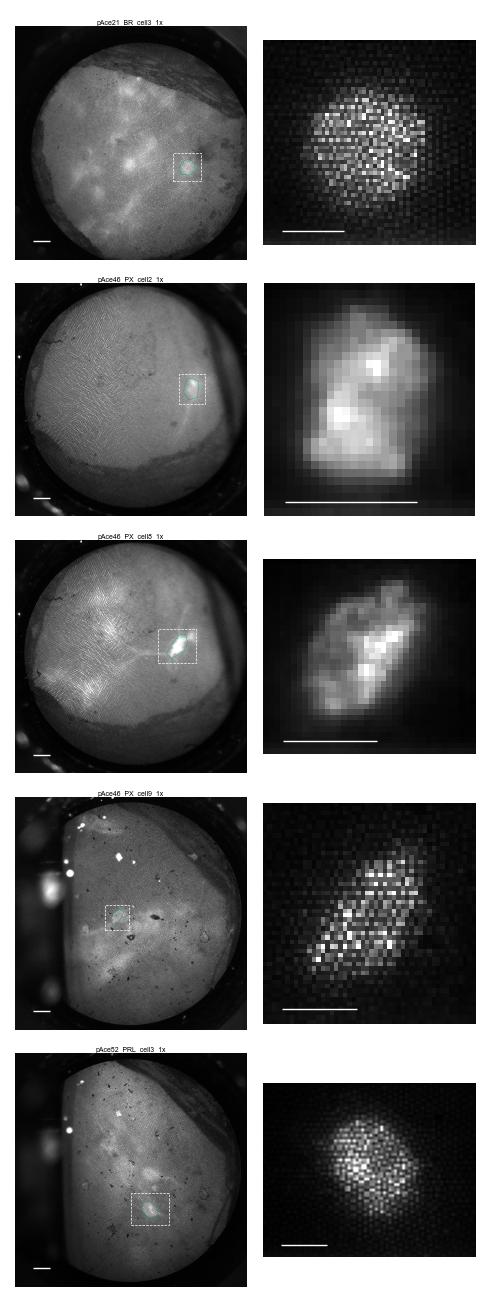

In [17]:
from pathlib import Path
import math
import re
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from matplotlib.patches import Polygon, Rectangle

slm_root = Path('/Volumes/QixinT9/AdamLab/Data/SLM_data')
overlay_1x_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_polygon_rectangle_overlay_all_1x.svg')
left_vmin_percentile = 0.0
left_vmax_percentile = 99.9
left_vmin = None
left_vmax = None
right_vmin_percentile = 0.0
right_vmax_percentile = 99.5
right_vmin = None
right_vmax = None
overlay_transpose = False
polygon_linewidth = 0.25
rectangle_linewidth = 0.5
base_pixel_size_um = 0.59
scale_bar_um = 20.0
scale_bar_linewidth = 1.0
overlay_xlim = (335, 800)
overlay_ylim = (330, 800)
overlay_row_height = 2.6
overlay_col_width_left = 2.6
overlay_col_width_right = 2.2

def load_single_plane_tif(image_path):
    image = tifffile.imread(image_path)
    image = np.asarray(image, dtype=float)
    if image.ndim > 2:
        image = image.mean(axis=0)
    return image

def parse_points_attribute(points_text):
    values = [float(value) for value in re.split(r'[ ,]+', points_text.strip()) if value]
    return np.asarray(values, dtype=float).reshape(-1, 2)

def parse_point_string(point_text):
    x_str, y_str = [value.strip() for value in point_text.split(',')]
    return float(x_str), float(y_str)

def find_first_polygon_points(xaml_path):
    root = ET.fromstring(xaml_path.read_text())
    for element in root.iter():
        if element.tag.endswith('ROIPoly') and 'Points' in element.attrib:
            return parse_points_attribute(element.attrib['Points'])
    return None

def find_first_rectangle_bounds(xaml_path):
    root = ET.fromstring(xaml_path.read_text())
    for element in root.iter():
        if element.tag.endswith('ROIRect'):
            top_left = parse_point_string(element.attrib['TopLeft'])
            bottom_right = parse_point_string(element.attrib['BottomRight'])
            return top_left, bottom_right
    raise ValueError(f'No ROIRect found in {xaml_path}')

def maybe_transpose_points(points, transpose):
    if points is None:
        return None
    points = np.asarray(points, dtype=float)
    return points[:, ::-1] if transpose else points

def maybe_transpose_rectangle(top_left, bottom_right, transpose):
    if not transpose:
        return top_left, bottom_right
    return (top_left[1], top_left[0]), (bottom_right[1], bottom_right[0])

def get_overlay_limits(image_shape, x_limits, y_limits):
    image_height, image_width = image_shape
    scale = 1.0 if (image_height > 1000 and image_width > 1000) else 0.5
    scaled_xlim = tuple(limit * scale for limit in x_limits)
    scaled_ylim = tuple(limit * scale for limit in y_limits)
    return scaled_xlim, scaled_ylim

def get_scale_bar_pixels(image_shape):
    image_height, image_width = image_shape
    pixel_size_um = base_pixel_size_um if (image_height > 1000 and image_width > 1000) else base_pixel_size_um * 2
    return scale_bar_um / pixel_size_um

def add_image_scale_bar(ax, x_limits, y_limits, image_shape):
    scale_bar_pixels = get_scale_bar_pixels(image_shape)
    x0 = x_limits[0] + 0.08 * (x_limits[1] - x_limits[0])
    y0 = y_limits[0] + 0.08 * (y_limits[1] - y_limits[0])
    ax.plot([x0, x0 + scale_bar_pixels], [y0, y0], color='white', linewidth=scale_bar_linewidth, solid_capstyle='butt')

matching_1x_folders = []
for folder in sorted(path for path in slm_root.iterdir() if path.is_dir() and path.name.endswith('_1x')):
    tif_candidates = sorted(path for path in folder.glob('*.tif') if not path.name.startswith('._') and 'wf' in path.name.lower() and 'full' in path.name.lower())
    roi_candidates = sorted(path for path in folder.glob('*.tif') if not path.name.startswith('._') and 'mean' in path.name.lower())
    xaml_candidates = sorted(path for path in folder.glob('*ROIs.xaml') if not path.name.startswith('._'))
    if tif_candidates and xaml_candidates:
        roi_tif_path = roi_candidates[0] if roi_candidates else None
        matching_1x_folders.append((folder, tif_candidates[0], xaml_candidates[0], roi_tif_path))

print(f'Found {len(matching_1x_folders)} 1x folders with WF/full TIFF and ROIs.xaml:')
for folder, tif_path, xaml_path, roi_tif_path in matching_1x_folders:
    print(f'  {folder} | roi_tif={roi_tif_path.name if roi_tif_path is not None else "None"}')

n_panels = len(matching_1x_folders)
nrows = max(1, n_panels)
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(overlay_col_width_left + overlay_col_width_right, overlay_row_height * nrows),
    gridspec_kw={'width_ratios': [overlay_col_width_left, overlay_col_width_right]},
)
axes = np.atleast_2d(axes)

for ax in axes.ravel():
    ax.set_visible(False)

for row_idx, (folder, tif_path, xaml_path, roi_tif_path) in enumerate(matching_1x_folders):
    ax_left, ax_right = axes[row_idx]
    overlay_image = load_single_plane_tif(tif_path)
    display_image = overlay_image.T if overlay_transpose else overlay_image
    display_vmin = left_vmin
    display_vmax = left_vmax
    if display_vmin is None or display_vmax is None:
        percentile_vmin, percentile_vmax = np.nanpercentile(display_image, [left_vmin_percentile, left_vmax_percentile])
        if display_vmin is None:
            display_vmin = percentile_vmin
        if display_vmax is None:
            display_vmax = percentile_vmax
    polygon_points = maybe_transpose_points(find_first_polygon_points(xaml_path), overlay_transpose)
    rect_top_left, rect_bottom_right = maybe_transpose_rectangle(*find_first_rectangle_bounds(xaml_path), overlay_transpose)
    display_xlim, display_ylim = get_overlay_limits(display_image.shape, overlay_xlim, overlay_ylim)
    ax_left.set_visible(True)
    ax_left.imshow(display_image, cmap='gray', vmin=display_vmin, vmax=display_vmax)
    if polygon_points is not None:
        ax_left.add_patch(Polygon(polygon_points, closed=True, fill=False, edgecolor=COLOR_1X, linewidth=polygon_linewidth))
    ax_left.add_patch(Rectangle(rect_top_left, rect_bottom_right[0] - rect_top_left[0], rect_bottom_right[1] - rect_top_left[1], fill=False, edgecolor='white', linewidth=rectangle_linewidth, linestyle='--'))
    ax_left.set_axis_off()
    ax_left.set_xlim(*display_xlim)
    ax_left.set_ylim(*display_ylim)
    add_image_scale_bar(ax_left, display_xlim, display_ylim, display_image.shape)
    ax_left.set_title(folder.name, fontsize=5, pad=1)

    if roi_tif_path is not None:
        roi_image = load_single_plane_tif(roi_tif_path)
        roi_display_image = np.fliplr(roi_image)
        roi_vmin = right_vmin
        roi_vmax = right_vmax
        if roi_vmin is None or roi_vmax is None:
            roi_percentile_vmin, roi_percentile_vmax = np.nanpercentile(roi_display_image, [right_vmin_percentile, right_vmax_percentile])
            if roi_vmin is None:
                roi_vmin = roi_percentile_vmin
            if roi_vmax is None:
                roi_vmax = roi_percentile_vmax
        ax_right.set_visible(True)
        ax_right.imshow(roi_display_image, cmap='gray', vmin=roi_vmin, vmax=roi_vmax)
        ax_right.set_axis_off()
        roi_xlim = (0, roi_display_image.shape[1])
        roi_ylim = (roi_display_image.shape[0], 0)
        add_image_scale_bar(ax_right, roi_xlim, roi_ylim, roi_display_image.shape)

fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.98, wspace=0.03, hspace=0.10)
fig.savefig(overlay_1x_figure_path, format='svg', bbox_inches='tight')
print(f'Saved combined 1x overlay figure to {overlay_1x_figure_path} with overlay_transpose={overlay_transpose}')
plt.show()


<tifffile.TiffFile 'pAce24_WR_cell7_20x_WF_full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce34_BL_cell10_20x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce34_BL_cell3_20x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce34_BL_cell8_20x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce52_BRR_cell…WF-1x-full-3.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce52_BRR_cell6…x_WF-full-6.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')
<tifffile.TiffFile 'pAce52_PRL_cell1_20x_WF-full.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')


Found 7 20x folders with WF/full TIFF and ROIs.xaml:
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce24_WR_cell7_20x | roi_tif=pAce24_WR-20X-cell7_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce34_BL_cell10_20x | roi_tif=pAce34_BL-cell10-20x_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce34_BL_cell3_20x | roi_tif=pAce34_BL-cell3-20x_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce34_BL_cell8_20x | roi_tif=pAce34_BL-cell8-20x_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_BRR_cell3_20x | roi_tif=pAce52_BRR-20x-cell3_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_BRR_cell6_20x | roi_tif=pAce52_BRR-20x-cell6_mean_0500_1500.tif
  /Volumes/QixinT9/AdamLab/Data/SLM_data/pAce52_PRL_cell1_20x | roi_tif=pAce52_PRL-20x-cell1_mean_0500_1500.tif
Saved combined 20x overlay figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_polygon_rectangle_overlay_al

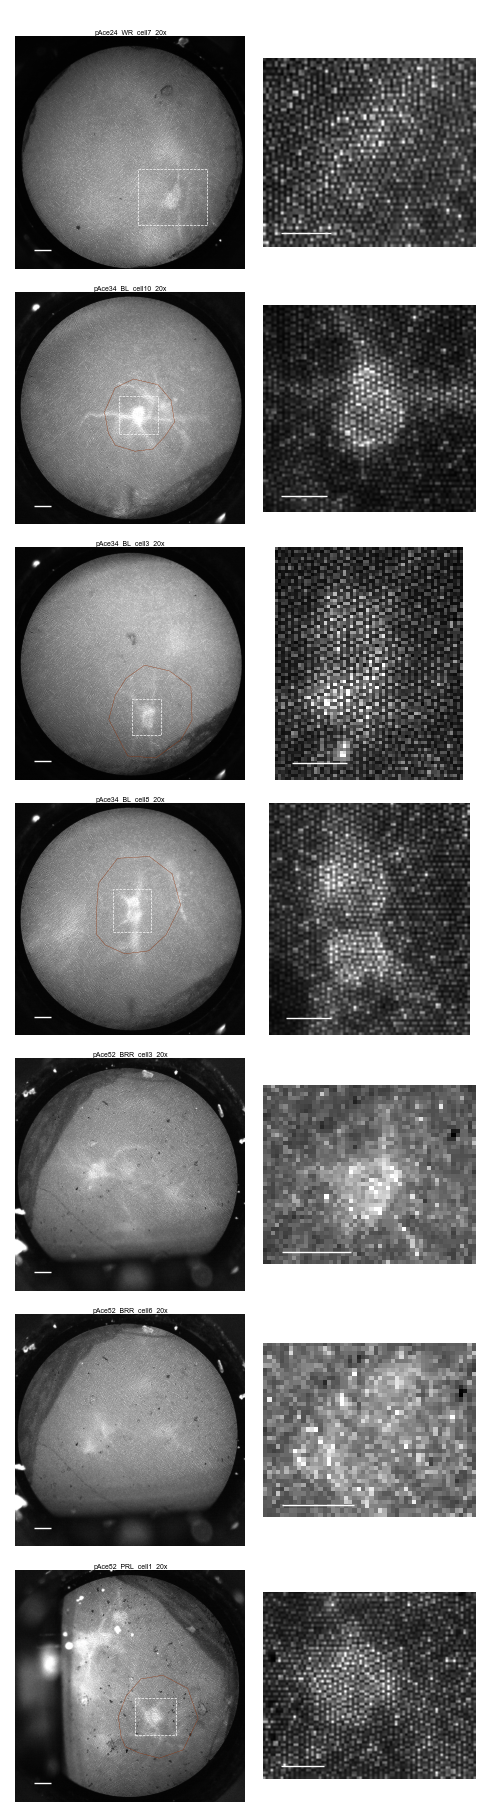

In [18]:
from pathlib import Path
import math
import re
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from matplotlib.patches import Polygon, Rectangle

slm_root = Path('/Volumes/QixinT9/AdamLab/Data/SLM_data')
overlay_20x_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_polygon_rectangle_overlay_all_20x.svg')
left_vmin_percentile = 0.0
left_vmax_percentile = 99.5
left_vmin = None
left_vmax = None
right_vmin_percentile = 0.0
right_vmax_percentile = 99.5
right_vmin = None
right_vmax = None
overlay_transpose = False
polygon_linewidth = 0.25
rectangle_linewidth = 0.5
base_pixel_size_um = 0.59
scale_bar_um = 20.0
scale_bar_linewidth = 1.0
overlay_xlim = (335, 800)
overlay_ylim = (330, 800)
overlay_row_height = 2.6
overlay_col_width_left = 2.6
overlay_col_width_right = 2.2

def load_single_plane_tif(image_path):
    image = tifffile.imread(image_path)
    image = np.asarray(image, dtype=float)
    if image.ndim > 2:
        image = image.mean(axis=0)
    return image

def parse_points_attribute(points_text):
    values = [float(value) for value in re.split(r'[ ,]+', points_text.strip()) if value]
    return np.asarray(values, dtype=float).reshape(-1, 2)

def parse_point_string(point_text):
    x_str, y_str = [value.strip() for value in point_text.split(',')]
    return float(x_str), float(y_str)

def find_first_polygon_points(xaml_path):
    root = ET.fromstring(xaml_path.read_text())
    for element in root.iter():
        if element.tag.endswith('ROIPoly') and 'Points' in element.attrib:
            return parse_points_attribute(element.attrib['Points'])
    return None

def find_first_rectangle_bounds(xaml_path):
    root = ET.fromstring(xaml_path.read_text())
    for element in root.iter():
        if element.tag.endswith('ROIRect'):
            top_left = parse_point_string(element.attrib['TopLeft'])
            bottom_right = parse_point_string(element.attrib['BottomRight'])
            return top_left, bottom_right
    raise ValueError(f'No ROIRect found in {xaml_path}')

def maybe_transpose_points(points, transpose):
    if points is None:
        return None
    points = np.asarray(points, dtype=float)
    return points[:, ::-1] if transpose else points

def maybe_transpose_rectangle(top_left, bottom_right, transpose):
    if not transpose:
        return top_left, bottom_right
    return (top_left[1], top_left[0]), (bottom_right[1], bottom_right[0])

def get_overlay_limits(image_shape, x_limits, y_limits):
    image_height, image_width = image_shape
    scale = 1.0 if (image_height > 1000 and image_width > 1000) else 0.5
    scaled_xlim = tuple(limit * scale for limit in x_limits)
    scaled_ylim = tuple(limit * scale for limit in y_limits)
    return scaled_xlim, scaled_ylim

def get_scale_bar_pixels(image_shape):
    image_height, image_width = image_shape
    pixel_size_um = base_pixel_size_um if (image_height > 1000 and image_width > 1000) else base_pixel_size_um * 2
    return scale_bar_um / pixel_size_um

def add_image_scale_bar(ax, x_limits, y_limits, image_shape):
    scale_bar_pixels = get_scale_bar_pixels(image_shape)
    x0 = x_limits[0] + 0.08 * (x_limits[1] - x_limits[0])
    y0 = y_limits[0] + 0.08 * (y_limits[1] - y_limits[0])
    ax.plot([x0, x0 + scale_bar_pixels], [y0, y0], color='white', linewidth=scale_bar_linewidth, solid_capstyle='butt')

matching_20x_folders = []
for folder in sorted(path for path in slm_root.iterdir() if path.is_dir() and path.name.endswith('_20x')):
    tif_candidates = sorted(path for path in folder.glob('*.tif') if not path.name.startswith('._') and 'wf' in path.name.lower() and 'full' in path.name.lower())
    roi_candidates = sorted(path for path in folder.glob('*.tif') if not path.name.startswith('._') and 'mean' in path.name.lower())
    xaml_candidates = sorted(path for path in folder.glob('*ROIs.xaml') if not path.name.startswith('._'))
    if tif_candidates and xaml_candidates:
        roi_tif_path = roi_candidates[0] if roi_candidates else None
        matching_20x_folders.append((folder, tif_candidates[0], xaml_candidates[0], roi_tif_path))

print(f'Found {len(matching_20x_folders)} 20x folders with WF/full TIFF and ROIs.xaml:')
for folder, tif_path, xaml_path, roi_tif_path in matching_20x_folders:
    print(f'  {folder} | roi_tif={roi_tif_path.name if roi_tif_path is not None else "None"}')

n_panels = len(matching_20x_folders)
nrows = max(1, n_panels)
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(overlay_col_width_left + overlay_col_width_right, overlay_row_height * nrows),
    gridspec_kw={'width_ratios': [overlay_col_width_left, overlay_col_width_right]},
)
axes = np.atleast_2d(axes)

for ax in axes.ravel():
    ax.set_visible(False)

for row_idx, (folder, tif_path, xaml_path, roi_tif_path) in enumerate(matching_20x_folders):
    ax_left, ax_right = axes[row_idx]
    overlay_image = load_single_plane_tif(tif_path)
    display_image = overlay_image.T if overlay_transpose else overlay_image
    display_vmin = left_vmin
    display_vmax = left_vmax
    if display_vmin is None or display_vmax is None:
        percentile_vmin, percentile_vmax = np.nanpercentile(display_image, [left_vmin_percentile, left_vmax_percentile])
        if display_vmin is None:
            display_vmin = percentile_vmin
        if display_vmax is None:
            display_vmax = percentile_vmax
    polygon_points = maybe_transpose_points(find_first_polygon_points(xaml_path), overlay_transpose)
    rect_top_left, rect_bottom_right = maybe_transpose_rectangle(*find_first_rectangle_bounds(xaml_path), overlay_transpose)
    display_xlim, display_ylim = get_overlay_limits(display_image.shape, overlay_xlim, overlay_ylim)
    ax_left.set_visible(True)
    ax_left.imshow(display_image, cmap='gray', vmin=display_vmin, vmax=display_vmax)
    if polygon_points is not None:
        ax_left.add_patch(Polygon(polygon_points, closed=True, fill=False, edgecolor=COLOR_20X, linewidth=polygon_linewidth))
    ax_left.add_patch(Rectangle(rect_top_left, rect_bottom_right[0] - rect_top_left[0], rect_bottom_right[1] - rect_top_left[1], fill=False, edgecolor='white', linewidth=rectangle_linewidth, linestyle='--'))
    ax_left.set_axis_off()
    ax_left.set_xlim(*display_xlim)
    ax_left.set_ylim(*display_ylim)
    add_image_scale_bar(ax_left, display_xlim, display_ylim, display_image.shape)
    ax_left.set_title(folder.name, fontsize=5, pad=1)

    if roi_tif_path is not None:
        roi_image = load_single_plane_tif(roi_tif_path)
        roi_display_image = np.fliplr(roi_image)
        roi_vmin = right_vmin
        roi_vmax = right_vmax
        if roi_vmin is None or roi_vmax is None:
            roi_percentile_vmin, roi_percentile_vmax = np.nanpercentile(roi_display_image, [right_vmin_percentile, right_vmax_percentile])
            if roi_vmin is None:
                roi_vmin = roi_percentile_vmin
            if roi_vmax is None:
                roi_vmax = roi_percentile_vmax
        ax_right.set_visible(True)
        ax_right.imshow(roi_display_image, cmap='gray', vmin=roi_vmin, vmax=roi_vmax)
        ax_right.set_axis_off()
        roi_xlim = (0, roi_display_image.shape[1])
        roi_ylim = (roi_display_image.shape[0], 0)
        add_image_scale_bar(ax_right, roi_xlim, roi_ylim, roi_display_image.shape)

fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.98, wspace=0.03, hspace=0.10)
fig.savefig(overlay_20x_figure_path, format='svg', bbox_inches='tight')
print(f'Saved combined 20x overlay figure to {overlay_20x_figure_path} with overlay_transpose={overlay_transpose}')
plt.show()


<tifffile.TiffFile '488-cell16-1x_001.tif'> OME series raised ParseError('not well-formed (invalid token): line 1, column 557')


Saved ROI overlay figure to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_rep_cell_WF_cell16_roi_overlay.svg


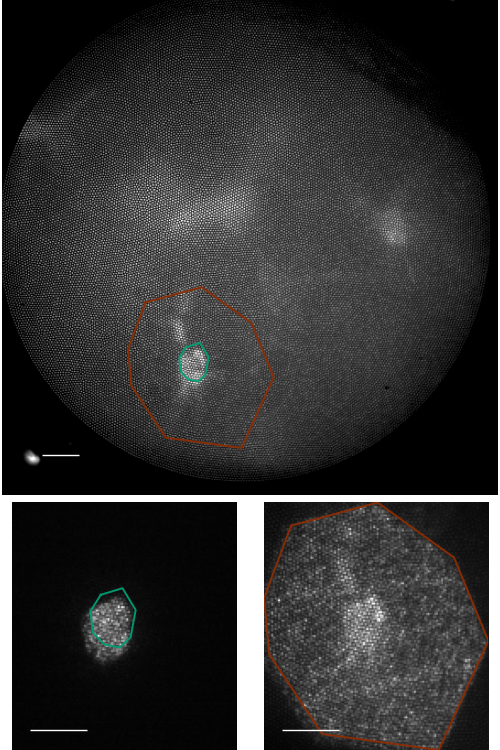

Displayed WF overlay plus 488 1x and 488 20x panels with 1 1x contour(s) and 1 20x contour(s).


In [19]:
from pathlib import Path
import re
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import tifffile

rep_cell_wf_image_path = Path('/Volumes/QixinT9/AdamLab/Data/SLM_rep_cell/WF-cell16_full-001.tif')
rep_cell_1x_image_path = Path('/Volumes/QixinT9/AdamLab/Data/SLM_rep_cell/488-cell16-1x_001.tif')
rep_cell_20x_image_path = Path('/Volumes/QixinT9/AdamLab/Data/SLM_rep_cell/488-cell16-20x_adj-001.tif')
roi_1x_xaml_path = Path('/Volumes/QixinT9/AdamLab/Data/SLM_rep_cell/1x_pre_15s_ROIs.xaml')
roi_20x_xaml_path = Path('/Volumes/QixinT9/AdamLab/Data/SLM_rep_cell/20x_pre_15s_ROIs.xaml')
roi_overlay_figure_path = Path('/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/Figure1_code/SLM_rep_cell_WF_cell16_roi_overlay.svg')

roi_overlay_linewidth = 1.4
roi_overlay_alpha = 0.95
roi_overlay_xlim = (350, 800)
roi_overlay_ylim = (350, 800)
roi_overlay_vmin_percentile = 0.2
roi_overlay_vmax_percentile = 100
base_pixel_size_um = 0.59
scale_bar_um = 20.0
scale_bar_linewidth = 1.0

for required_path in [rep_cell_wf_image_path, rep_cell_1x_image_path, rep_cell_20x_image_path, roi_1x_xaml_path, roi_20x_xaml_path]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)


def load_single_plane_tif(image_path):
    image = np.asarray(tifffile.imread(image_path), dtype=float)
    if image.ndim == 4:
        image = image.mean(axis=0)
    if image.ndim == 3 and image.shape[-1] not in (3, 4):
        image = image.mean(axis=0)
    return image


def parse_points_attribute(points_text):
    values = [float(value) for value in re.split(r'[ ,]+', points_text.strip()) if value]
    return np.asarray(values, dtype=float).reshape(-1, 2)


def read_unique_roi_polygons(xaml_path):
    root = ET.fromstring(xaml_path.read_text())
    polygons = []
    seen = set()
    for element in root.iter():
        if element.tag.endswith('ROIPoly') and 'Points' in element.attrib:
            points = parse_points_attribute(element.attrib['Points'])
            key = tuple(np.round(points, decimals=3).ravel())
            if key in seen:
                continue
            seen.add(key)
            polygons.append(points)
    if not polygons:
        raise ValueError(f'No ROIPoly contours found in {xaml_path}')
    return polygons


def close_polygon(points):
    points = np.asarray(points, dtype=float)
    if points.shape[0] > 1 and not np.allclose(points[0], points[-1]):
        points = np.vstack([points, points[0]])
    return points


def get_image_display_limits(image, image_path):
    finite_values = image[np.isfinite(image)]
    if finite_values.size == 0:
        raise ValueError(f'Image contains no finite values: {image_path}')
    vmin, vmax = np.percentile(
        finite_values,
        [roi_overlay_vmin_percentile, roi_overlay_vmax_percentile],
    )
    if vmax <= vmin:
        vmin, vmax = float(finite_values.min()), float(finite_values.max())
    return vmin, vmax


def get_polygon_enclosing_limits(polygons):
    all_points = np.vstack(polygons)
    x_min = float(np.nanmin(all_points[:, 0]))
    x_max = float(np.nanmax(all_points[:, 0]))
    y_min = float(np.nanmin(all_points[:, 1]))
    y_max = float(np.nanmax(all_points[:, 1]))
    return (x_min, x_max), (y_min, y_max)


def apply_roi_crop(ax, x_limits, y_limits):
    ax.set_xlim(*x_limits)
    ax.set_ylim(y_limits[1], y_limits[0])
    ax.set_aspect('equal')
    ax.axis('off')


def get_scale_bar_pixels(image_shape):
    image_height, image_width = image_shape[:2]
    pixel_size_um = base_pixel_size_um if (image_height > 1000 and image_width > 1000) else base_pixel_size_um * 2
    return scale_bar_um / pixel_size_um


def add_image_scale_bar(ax, image_shape, x_limits, y_limits):
    scale_bar_pixels = get_scale_bar_pixels(image_shape)
    x_min, x_max = x_limits
    y_min, y_max = y_limits
    x0 = x_min + 0.08 * (x_max - x_min)
    y0 = y_max - 0.08 * (y_max - y_min)
    ax.plot(
        [x0, x0 + scale_bar_pixels],
        [y0, y0],
        color='white',
        linewidth=scale_bar_linewidth,
        solid_capstyle='butt',
        zorder=10,
    )


def plot_image_with_contours(ax, image, image_path, contour_specs, x_limits, y_limits):
    vmin, vmax = get_image_display_limits(image, image_path)
    ax.imshow(image, cmap='gray', vmin=vmin, vmax=vmax, origin='upper')
    for polygons, color in contour_specs:
        for polygon in polygons:
            points = close_polygon(polygon)
            ax.plot(
                points[:, 0],
                points[:, 1],
                color=color,
                linewidth=roi_overlay_linewidth,
                alpha=roi_overlay_alpha,
            )
    apply_roi_crop(ax, x_limits, y_limits)
    add_image_scale_bar(ax, image.shape, x_limits, y_limits)


rep_cell_wf_image = load_single_plane_tif(rep_cell_wf_image_path)
rep_cell_1x_image = load_single_plane_tif(rep_cell_1x_image_path)
rep_cell_20x_image = load_single_plane_tif(rep_cell_20x_image_path)
roi_polygons_1x = read_unique_roi_polygons(roi_1x_xaml_path)
roi_polygons_20x = read_unique_roi_polygons(roi_20x_xaml_path)
bottom_roi_xlim, bottom_roi_ylim = get_polygon_enclosing_limits(roi_polygons_20x)
roi_color_1x = globals().get('COLOR_1X', '#009E73')
roi_color_20x = globals().get('COLOR_20X', '#8C2D04')

fig = plt.figure(figsize=(5, 7.5))
gridspec = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.02, wspace=0.02)
ax_wf = fig.add_subplot(gridspec[0, :])
ax_1x = fig.add_subplot(gridspec[1, 0])
ax_20x = fig.add_subplot(gridspec[1, 1])

plot_image_with_contours(
    ax_wf,
    rep_cell_wf_image,
    rep_cell_wf_image_path,
    [(roi_polygons_1x, roi_color_1x), (roi_polygons_20x, roi_color_20x)],
    roi_overlay_xlim,
    roi_overlay_ylim,
)
plot_image_with_contours(
    ax_1x,
    rep_cell_1x_image,
    rep_cell_1x_image_path,
    [(roi_polygons_1x, roi_color_1x)],
    bottom_roi_xlim,
    bottom_roi_ylim,
)
plot_image_with_contours(
    ax_20x,
    rep_cell_20x_image,
    rep_cell_20x_image_path,
    [(roi_polygons_20x, roi_color_20x)],
    bottom_roi_xlim,
    bottom_roi_ylim,
)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.02, wspace=0.02)
fig.savefig(roi_overlay_figure_path, format='svg', bbox_inches='tight', pad_inches=0)
print(f'Saved ROI overlay figure to {roi_overlay_figure_path}')
plt.show()

print(
    f'Displayed WF overlay plus 488 1x and 488 20x panels with '
    f'{len(roi_polygons_1x)} 1x contour(s) and {len(roi_polygons_20x)} 20x contour(s).'
)
